In [34]:
from typing import Set, Tuple

import numpy as np
import pandas as pd

import soccer_one_twos_extractor.models.xthreath as xthreat
from soccer_one_twos_extractor.constants.fields import F
from soccer_one_twos_extractor.pipeline.pipe import MetricPipeline
from soccer_one_twos_extractor.utils.plotting import (
    plot_one_twos_heatmap,
    plot_one_twos_per_90,
    plot_onetwos_chance_creation,
    plot_onetwos_scatter_player,
    plot_team_one_twos,
)

# Folder inputs

In [35]:
data_folder_path = "../data"
logos_folder_path = "../assets"
fbref_csv_file = "fbref_playersdb.csv"

# Metric Extraction

### Helper functions

In [3]:
def get_duos_common_minutes(
    association_metric_df: pd.DataFrame,
    players_data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute the total minutes two players (who formed a one–two) were
    simultaneously on the pitch for the same team and match.
    """
    d = players_data.copy()

    # --- 1) Build the set of undirected pairs from one–twos (by names) ---
    pairs: Set[Tuple[str, str]] = {
        tuple(sorted((str(a), str(b))))
        for a, b in association_metric_df[["player_A_name", "player_B_name"]]
        .dropna()
        .itertuples(index=False, name=None)
    }  # type: ignore

    # --- 2) Ensure on/off seconds exist (MM:SS -> seconds) ---
    if "player_on_s" not in d.columns or "player_off_s" not in d.columns:
        for col in ["player_on", "player_off"]:
            mmss = d[col].fillna("0:00").astype(str).str.split(":", expand=True)
            mins = pd.to_numeric(mmss[0], errors="coerce").fillna(0).astype(int)
            secs = pd.to_numeric(mmss[1], errors="coerce").fillna(0).astype(int)
            d[f"{col}_s"] = mins * 60 + secs

    # --- 3) Self-join by (game, team) to form all within-team duos per match ---
    cm = d.merge(d, on=[F.GAME_ID, F.TEAM_NAME], suffixes=("_x", "_y"))

    # Keep unique player pairs (no self, no duplicates): order by player_id
    cm = cm[cm["player_id_x"] < cm["player_id_y"]].copy()
    cm = cm.dropna(subset=["player_x", "player_y"])

    # Undirected pair key by names to match association_metric_df
    cm["pair"] = list(
        map(
            lambda a, b: tuple(sorted((str(a), str(b)))), cm["player_x"], cm["player_y"]
        )
    )

    # --- 4) Overlapping minutes for the pair within the match ---
    cm["overlap"] = (
        np.minimum(cm["player_off_s_x"], cm["player_off_s_y"])
        - np.maximum(cm["player_on_s_x"], cm["player_on_s_y"])
    ).clip(lower=0) / 60.0  # minutes

    # Only pairs that actually formed a one–two
    cm = cm[cm["pair"].isin(pairs)]

    # --- 5) Aggregate across matches, split back to two columns, round ---
    result = (
        cm.groupby(["pair", F.TEAM_NAME], as_index=False)["overlap"]
        .sum()
        .rename(columns={"overlap": "common_minutes"})
    )  # type: ignore
    result[["player_1", "player_2"]] = pd.DataFrame(
        result["pair"].tolist(), index=result.index
    )
    result["common_minutes"] = result["common_minutes"].round(2)

    return result[["player_1", "player_2", F.TEAM_NAME, "common_minutes"]]


def merge_one_twos_with_player_names(
    one_twos_df: pd.DataFrame, players_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Merge one-twos event data with player names based on player IDs.
    """
    merged = one_twos_df.merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_A",
                "player": "player_A_name",
                "pos": "player_A_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_A"],
        how="left",
    ).merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_B",
                "player": "player_B_name",
                "pos": "player_B_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_B"],
        how="left",
    )
    return merged

### Get Progressive One Twos

In [36]:
_pipe = MetricPipeline(
    data_folder=data_folder_path,
    # F24 xml games folder path
    external_player_file=fbref_csv_file,
    # External player data (with player names) file path
    min_progression_ratio_pct=0.2,
    # Progression towars goal line or center point higher or equals 20%
    max_time_diff=5,
    # No more than 5 seconds between opening pass and returning pass
    max_player_b_ball_carry_distance=5,
    # One two closer (carry distance constraint)
    n_jobs=4,
    # Cores for parallel computation
)

(
    events_df,
    players_df,
    progressive_one_twos_df,
) = _pipe.parallel_run()

# Merge progressive one twos with player names data
progressive_one_twos_df_ = merge_one_twos_with_player_names(
    progressive_one_twos_df, players_df
)
# Get One twos Duos common minutes
onetwos_pairs_df = get_duos_common_minutes(progressive_one_twos_df_, players_df)

Parsing matches: 100%|██████████| 380/380 [01:13<00:00,  5.15it/s]


In [37]:
progressive_one_twos_df_

,game_id,event_id,type_id,period_id,min,sec,team_id,outcome,x_A,y_A,...,pass_end_x_B,pass_end_y_B,keypass_next_B,assist_next_B,shot_within_6s_after_B,secs_to_next_team_shot_B,player_A_name,player_A_position,player_B_name,player_B_position
0,2301587,172,1,1,27,25,181,1,70.245,57.868,...,90.825,64.668,0,0,0,363.0,Dani Rodríguez,LM,Jaume Costa,LB
1,2301587,321,1,1,38,2,174,1,55.440,35.292,...,69.3,14.62,0,0,0,269.0,Iker Muniain,LM,Óscar de Marcos,RB
2,2301587,362,1,1,43,21,174,1,78.225,3.604,...,94.5,11.084,1,0,1,3.0,Óscar de Marcos,RB,Mikel Vesga,CM
3,2301587,500,1,2,53,13,174,1,72.030,59.568,...,89.145,52.836,0,0,0,141.0,Álex Berenguer,LW,Yuri Berchiche,LB
4,2301587,762,1,2,84,13,174,1,74.025,50.320,...,93.24,50.184,0,0,0,11.0,Raúl García,FW,Yuri Berchiche,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302,2301966,428,1,2,49,50,450,1,75.285,64.396,...,85.05,56.304,0,0,1,3.0,Abde Ezzalzouli,LW,Aimar Oroz,LM
2303,2301966,532,1,2,66,23,450,1,72.975,13.396,...,84.84,16.66,0,0,0,1516.0,Ante Budimir,FW,Aimar Oroz,LM
2304,2301966,576,1,2,72,36,450,1,72.555,53.856,...,93.135,57.256,0,0,0,1142.0,Aimar Oroz,LM,Abde Ezzalzouli,LW
2305,2301966,851,1,2,85,24,2893,1,56.070,2.856,...,80.01,2.652,1,0,0,7.0,Yan Couto,RB,Viktor Tsyhankov,RM


# LALIGA 22-23 Progressive One twos Analysis

#### Prog. One twos team preview

In [38]:
import os
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from mplsoccer import Pitch, VerticalPitch
from PIL import Image


def plot_team_one_twos(one_twos_df: pd.DataFrame, team_name: str) -> None:
    """
    Plot all progressive one–twos made by a given team, match by match, on a
    105×68 pitch.

    For every match in `one_twos_df` where `team_name` appears (home or away),
    the function:
      • selects only the one–twos executed by `team_name` in that match,
      • draws the opening pass A→B (solid cyan), the return pass B→A (solid lime),
      • draws the receiver carry (A pass end → B pass start, dashed lime),
      • draws the overall exchange progression (A start → B pass end, dashed cyan),
      • annotates the minute (from `time_seconds_A`),
      • titles the figure with the full match scoreline.
    Matches with no rows for the team (after any upstream filtering)
    are skipped gracefully.

    Parameters
    ----------
    one_twos_df : pd.DataFrame
        Detected one–twos (typically your `progressive_one_twos_df_`), expected to
        contain at least:
          - Context: F.MATCH_NAME, F.TEAM_ID, F.HOME_TEAM_ID/NAME,
          F.AWAY_TEAM_ID/NAME, F.HOME_SCORE, F.AWAY_SCORE, "team_name"
          - Opening pass (A→B): f"{F.X}_A", f"{F.Y}_A", f"pass_end_{F.X}_A",
            f"pass_end_{F.Y}_A", f"{F.TIME}_A"
          - Return pass (B→A): f"{F.X}_B", f"{F.Y}_B", f"pass_end_{F.X}_B",
            f"pass_end_{F.Y}_B"
        Coordinates should already be normalized to a 105×68 pitch.
    team_name : str
        Team to visualize (exact string match against home/away team names).

    Returns
    -------
    None
        Displays one matplotlib figure per match. Requires `mplsoccer.Pitch`.

    Notes
    -----
    - This function assumes your global constant names come from `F` (fields enum)
      and that `Pitch` from `mplsoccer` is available in scope.
    - If you pre-filter `one_twos_df` (e.g., only key-pass cases), some matches may
      have zero one–twos for the team; those matches are skipped with a console note.
    """
    # matches where the team appears
    team_df = one_twos_df[
        (one_twos_df[F.HOME_TEAM_NAME] == team_name)
        | (one_twos_df[F.AWAY_TEAM_NAME] == team_name)
    ].copy()
    if team_df.empty:
        print(f"No one–twos found for team: {team_name}")
        return

    matches = team_df[F.MATCH_NAME].unique()

    for match in matches:
        match_df = team_df[team_df[F.MATCH_NAME] == match]

        # team_id for this match (home vs away)
        team_is_home = match_df[F.HOME_TEAM_NAME].iat[0] == team_name
        team_id = (
            match_df[F.HOME_TEAM_ID].iat[0]
            if team_is_home
            else match_df[F.AWAY_TEAM_ID].iat[0]
        )

        # only this team’s one–twos in this match
        match_team_df = match_df[match_df[F.TEAM_ID] == team_id]

        # --- guard: nothing to plot for this team in this match ---
        if match_team_df.empty:
            print(f"Skipping {match}: no {team_name} one–twos in current subset.")
            continue

        # draw pitch
        pitch = Pitch(
            pitch_type="custom",
            pitch_width=68,
            pitch_length=105,
            pitch_color="white",
            line_color="#17212d",
        )
        fig, ax = pitch.draw(figsize=(8, 8))  # type: ignore

        # plot arrows...
        for i, row in match_team_df.iterrows():
            pitch.arrows(
                row[f"{F.X}_A"],
                row[f"{F.Y}_A"],
                row[f"pass_end_{F.X}_A"],
                row[f"pass_end_{F.Y}_A"],
                width=2.5,
                headwidth=3,
                color="#17212d",
                ax=ax,
                label="First pass" if i == match_team_df.index[0] else "",
            )
            pitch.arrows(
                row[f"{F.X}_B"],
                row[f"{F.Y}_B"],
                row[f"pass_end_{F.X}_B"],
                row[f"pass_end_{F.Y}_B"],
                width=2.5,
                headwidth=3,
                color="lime",
                ax=ax,
                label="Return pass" if i == match_team_df.index[0] else "",
            )
            ax.plot(  # type: ignore
                [row[f"pass_end_{F.X}_A"], row[f"{F.X}_B"]],
                [row[f"pass_end_{F.Y}_A"], row[f"{F.Y}_B"]],
                ls="--",
                color="lime",
                lw=1,
                alpha=1,
            )
            ax.plot(  # type: ignore
                [row[f"{F.X}_A"], row[f"pass_end_{F.X}_B"]],
                [row[f"{F.Y}_A"], row[f"pass_end_{F.Y}_B"]],
                ls="--",
                color="#17212d",
                lw=1,
                alpha=1,
            )
            minute = int(row[f"{F.TIME}_A"] // 60)
            ax.text(  # type: ignore
                row[f"{F.X}_A"],
                row[f"{F.Y}_A"] + 1,
                f"{minute}′",
                fontsize=10,
                color="#17212d",
                ha="center",
                va="bottom",
            )

        # legend (dedupe)
        handles, labels = ax.get_legend_handles_labels()  # type: ignore
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(  # type: ignore
                by_label.values(), by_label.keys(), loc="upper left", fontsize=10
            )  # type: ignore

        # title from full match slice
        home_team = match_df[F.HOME_TEAM_NAME].iat[0]
        away_team = match_df[F.AWAY_TEAM_NAME].iat[0]
        home_score = match_df[F.HOME_SCORE].iat[0]
        away_score = match_df[F.AWAY_SCORE].iat[0]
        ax.set_title(  # type: ignore
            f"{team_name} One–Twos: {home_team} {home_score}–{away_score} {away_team}",
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()

#### Prog. One twos Sample leading to direct goals

In [8]:
# progressive_one_twos_df_[(progressive_one_twos_df_['team_name'] == "Celta de Vigo") & (progressive_one_twos_df_['x_A']>=70)]

In [9]:
# plot_team_one_twos(
#     progressive_one_twos_df_[progressive_one_twos_df_["keypass_B"] == "1"], "Celta de Vigo"
# )

### Prog. One twos rate (team level)

* What the chart shows. Teams ranked by their average progressive one-twos per game (blue bars), with thin whiskers showing match-to-match variability.

* Key reads. Real Madrid lead the league at ~5 one-twos per game. Eleven teams average ≥3; of those, six finished in the top half of the table that season. Notably, Sevilla and Valencia sit high on this metric despite not ending in the top half—evidence that one-two volume reflects style and individual quality more than overall league position on its own.

* One-twos are by definition combination play, but they’re not a direct proxy for overall strength. Villarreal illustrate this: lower volume, yet a higher conversion of one-twos into box chances—clear evidence of a quality-over-quantity approach.

In [39]:
def one_twos_per_100(
    events_df: pd.DataFrame,
    progressive_one_twos_df: pd.DataFrame,
    completed_only: bool = True,
) -> pd.DataFrame:
    """
    Compute progressive one-twos per 100 successful open-play passes,
    excluding set pieces (FK, corners, throw-ins) and launches.
    """

    exclude_ids = {
        "5",
        "6",
        "107",
        "157",
        "3",
        "168",
    }  # free kick taken, corner taken, throw-in, launch, headpass, flick on pass.

    passes = events_df[
        (events_df["event_name"].str.lower() == "pass")
        & (
            ~events_df["qualifiers"].apply(
                lambda q: any(
                    str(item.get("qualifier_id")) in exclude_ids for item in (q or [])
                )
            )
        )
    ]
    passes
    if completed_only and "outcome" in events_df:
        passes = passes[passes["outcome"].isin(["1"])]

    # Count totals
    passes_per_team = (
        passes.groupby("team_name")["event_id"].count().rename("total_passes")
    )
    one_twos_per_team = (
        progressive_one_twos_df.groupby("team_name").size().rename("total_one_twos")
    )

    # Combine and compute rate
    out = pd.concat([passes_per_team, one_twos_per_team], axis=1).fillna(0)
    out["one_twos_per_100_passes"] = (
        out["total_one_twos"] / out["total_passes"].replace(0, np.nan) * 100
    )

    return out.sort_values("one_twos_per_100_passes", ascending=False).reset_index()


def one_twos_per_game(progressive_one_twos_df: pd.DataFrame) -> pd.DataFrame:
    """
    Per game & team: total passes, total one-twos, and one-twos per 100 passes.
    """
    # one-twos per game-team
    one_twos_pg = (
        progressive_one_twos_df.groupby(["game_id", "team_name"], dropna=False)
        .size()
        .rename("total_one_twos")
    ).reset_index()
    # average per game (per team)
    out = (
        one_twos_pg.groupby("team_name", dropna=False)["total_one_twos"]
        .sum()
        .div(38.0)  # total league games per team
        .rename("one_twos_per_game")
        .reset_index()
        .sort_values("one_twos_per_game", ascending=False)
    )

    return out.sort_values(["one_twos_per_game"], ascending=[False]).reset_index(
        drop=True
    )


one_twos_per_100_ = one_twos_per_100(events_df, progressive_one_twos_df_, False)

one_twos_per_game_ = one_twos_per_game(progressive_one_twos_df_)

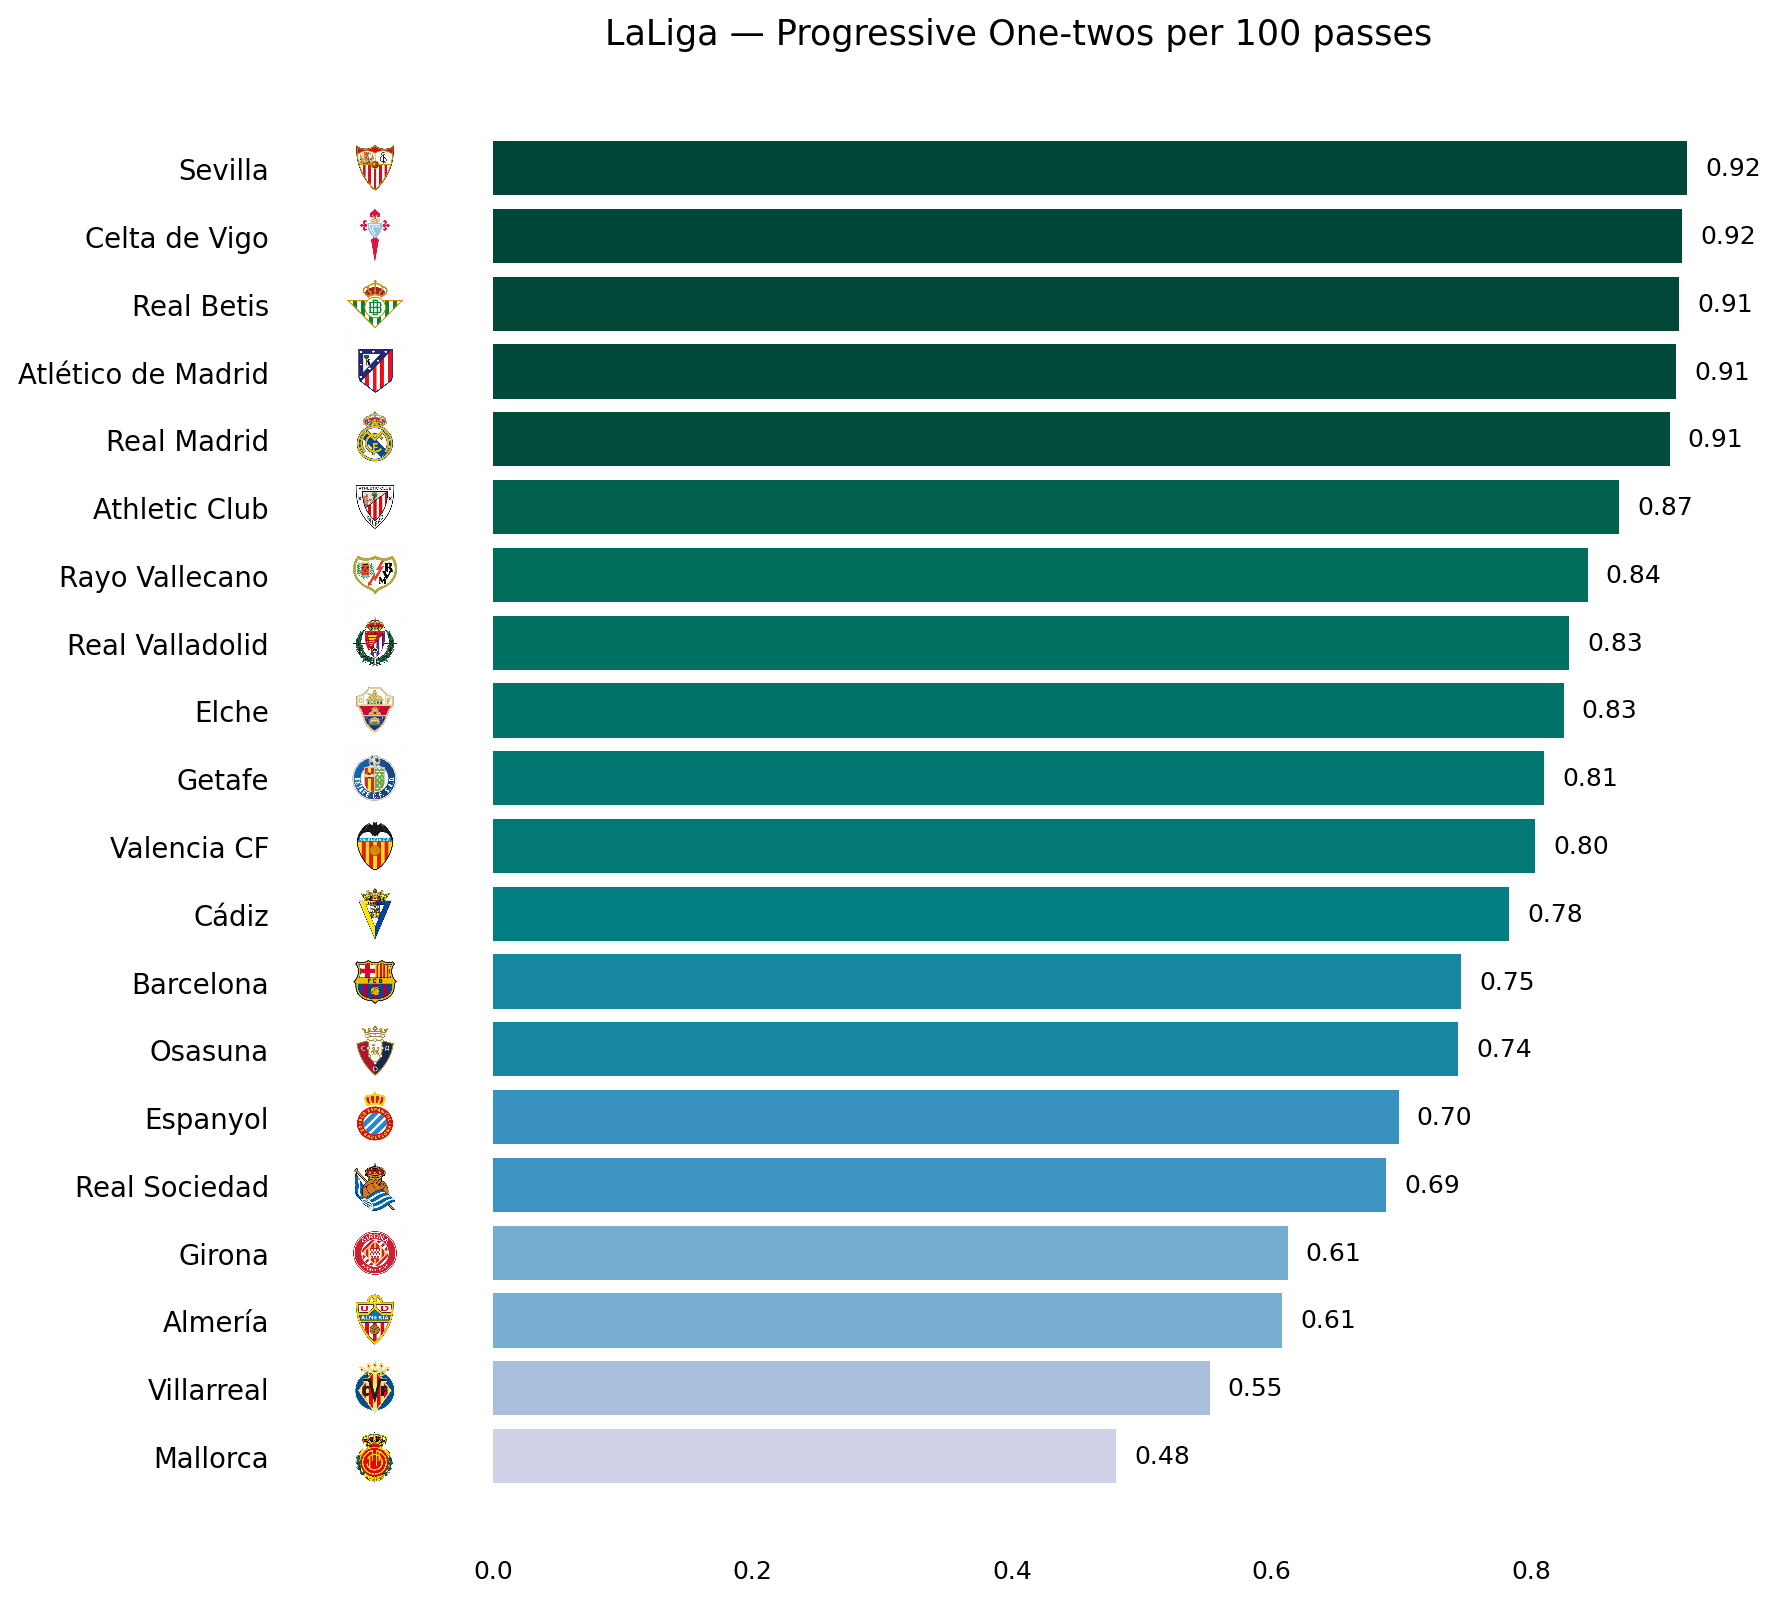

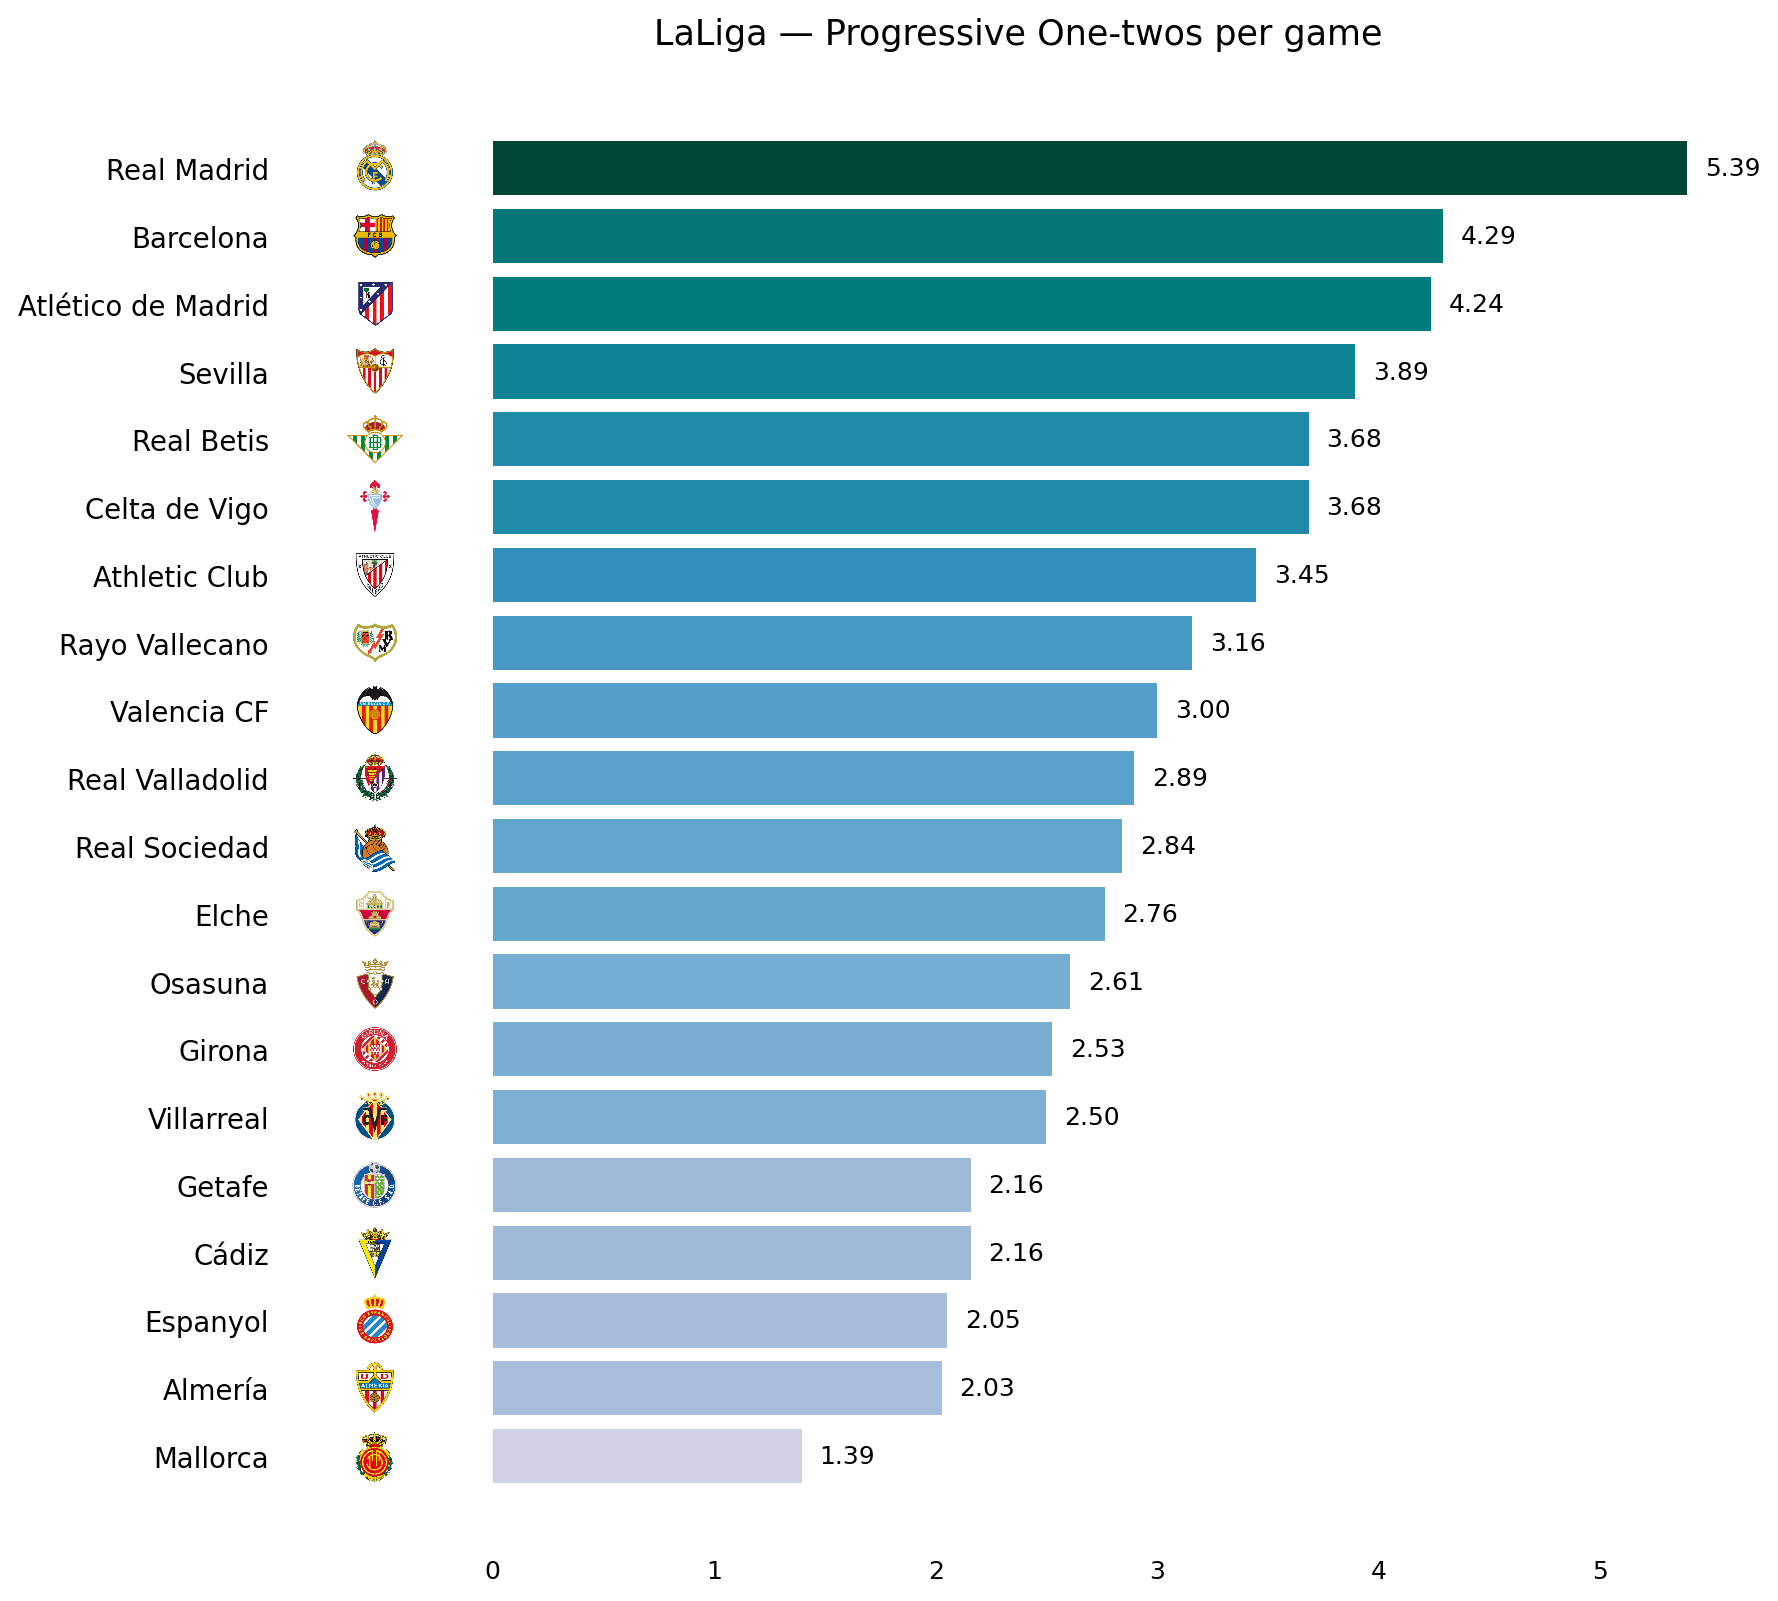

In [40]:
import re

from matplotlib import cm, colors


def _trunc_cmap(base_cmap, lo=0.25, hi=1.0, n=256):
    """Trim the pale end of a cmap (avoid white)."""
    return colors.LinearSegmentedColormap.from_list(
        f"trunc_{base_cmap.name}_{lo}_{hi}", base_cmap(np.linspace(lo, hi, n))
    )


def plot_one_twos_bar(
    df,
    logo_dir,
    team_col="team_name",
    kpi_col="one_twos_per_100_passes",
    title="LaLiga — One-twos per 100 passes",
    logo_zoom=0.085,
):
    # ---- data (descending) ----
    d = df[[team_col, kpi_col]].dropna().copy()
    d[kpi_col] = d[kpi_col].astype(float)
    d = d.sort_values(kpi_col, ascending=True).reset_index(drop=True)
    teams = d[team_col].tolist()
    vals = d[kpi_col].to_numpy()
    n = len(d)

    # ---- colors (truncate light end) ----
    cmap = _trunc_cmap(cm.PuBuGn, lo=0.25, hi=1.0)
    norm = colors.Normalize(vals.min(), vals.max())
    bar_colors = cmap(norm(vals))

    # ---- figure ----
    vmax = float(vals.max() if n else 1.0)
    pad = 0.18 * vmax  # room for logos on the left
    fig_h = max(4.0, 0.40 * n + 1.0)
    fig, ax = plt.subplots(figsize=(10, fig_h), dpi=180)  # higher DPI -> sharper logos

    ax.barh(range(n), vals, color=bar_colors, edgecolor="none")
    ax.set_yticks(range(n))
    ax.set_yticklabels(teams, fontsize=11)
    ax.set_xlim(-pad, vmax * 1.06)
    ax.set_title(title, fontsize=14, pad=12)

    # value labels
    for i, v in enumerate(vals):
        ax.text(v + vmax * 0.015, i, f"{v:.2f}", va="center", ha="left", fontsize=10)

    # clean look
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    # ---- logos (sharper) ----
    def _slug(s):  # simple matcher
        return re.sub(r"[^a-z0-9]+", "", s.lower())

    pngs = {
        os.path.splitext(f)[0]: os.path.join(logo_dir, f)
        for f in os.listdir(logo_dir)
        if f.lower().endswith(".png")
    }

    def _find_logo(name):
        exact = os.path.join(logo_dir, f"{name}.png")
        if os.path.exists(exact):
            return exact
        sn = _slug(name)
        for stem, path in pngs.items():
            if _slug(stem) == sn or _slug(stem).startswith(sn):
                return path
        return None

    for i, team in enumerate(teams):
        p = _find_logo(team)
        if not p:
            continue
        img = plt.imread(p)
        # Lanczos gives crisp downscaling; dpi_cor keeps physical size consistent
        oi = OffsetImage(img, zoom=logo_zoom, interpolation="lanczos", dpi_cor=True)
        ab = AnnotationBbox(
            oi, (-pad * 0.55, i), frameon=False, box_alignment=(0.5, 0.5)
        )
        ax.add_artist(ab)

    plt.tight_layout()
    plt.show()


# df has: team_name, total_passes, total_one_twos, one_twos_per_100_passes
plot_one_twos_bar(
    one_twos_per_100_,
    logo_dir=logos_folder_path,
    team_col="team_name",
    kpi_col="one_twos_per_100_passes",
    title="LaLiga — Progressive One-twos per 100 passes",
)

plot_one_twos_bar(
    one_twos_per_game_,
    logo_dir=logos_folder_path,
    team_col="team_name",
    kpi_col="one_twos_per_game",
    title="LaLiga — Progressive One-twos per game",
)

### Prog. One twos spatial distribution (team level)

* We map one-two openings (start of the wall-pass; circles/blue heat) using the start coordinates of the initial pass, and one-two closings (return pass; squares/green heat) using the end coordinates of the return pass.
Even without imposing any flank rule, the pattern lives mostly in the wide channels.

1. Side bias. Some teams funnel one-twos to a single flank—e.g., Sevilla, Real Sociedad, Elche—showing a clear right/left preference.

2. Variability. Others (e.g., Cádiz, Espanyol) show a broader spread of openings and closings across the width and height of the pitch. These teams tend to use some of their one twos to espace danger pressure zones.

3. Height. Most teams both open and close higher up the pitch. (in the final third area)

4. Closing zones. Many teams finish the combination in the wide zones around the 18-yard box, likely to set up a cut-back, cross, or key pass. In contrast, Villarreal and Real Madrid close more centrally, with Villarreal especially concentrated compared to the league leading to a higher one two efficiency.

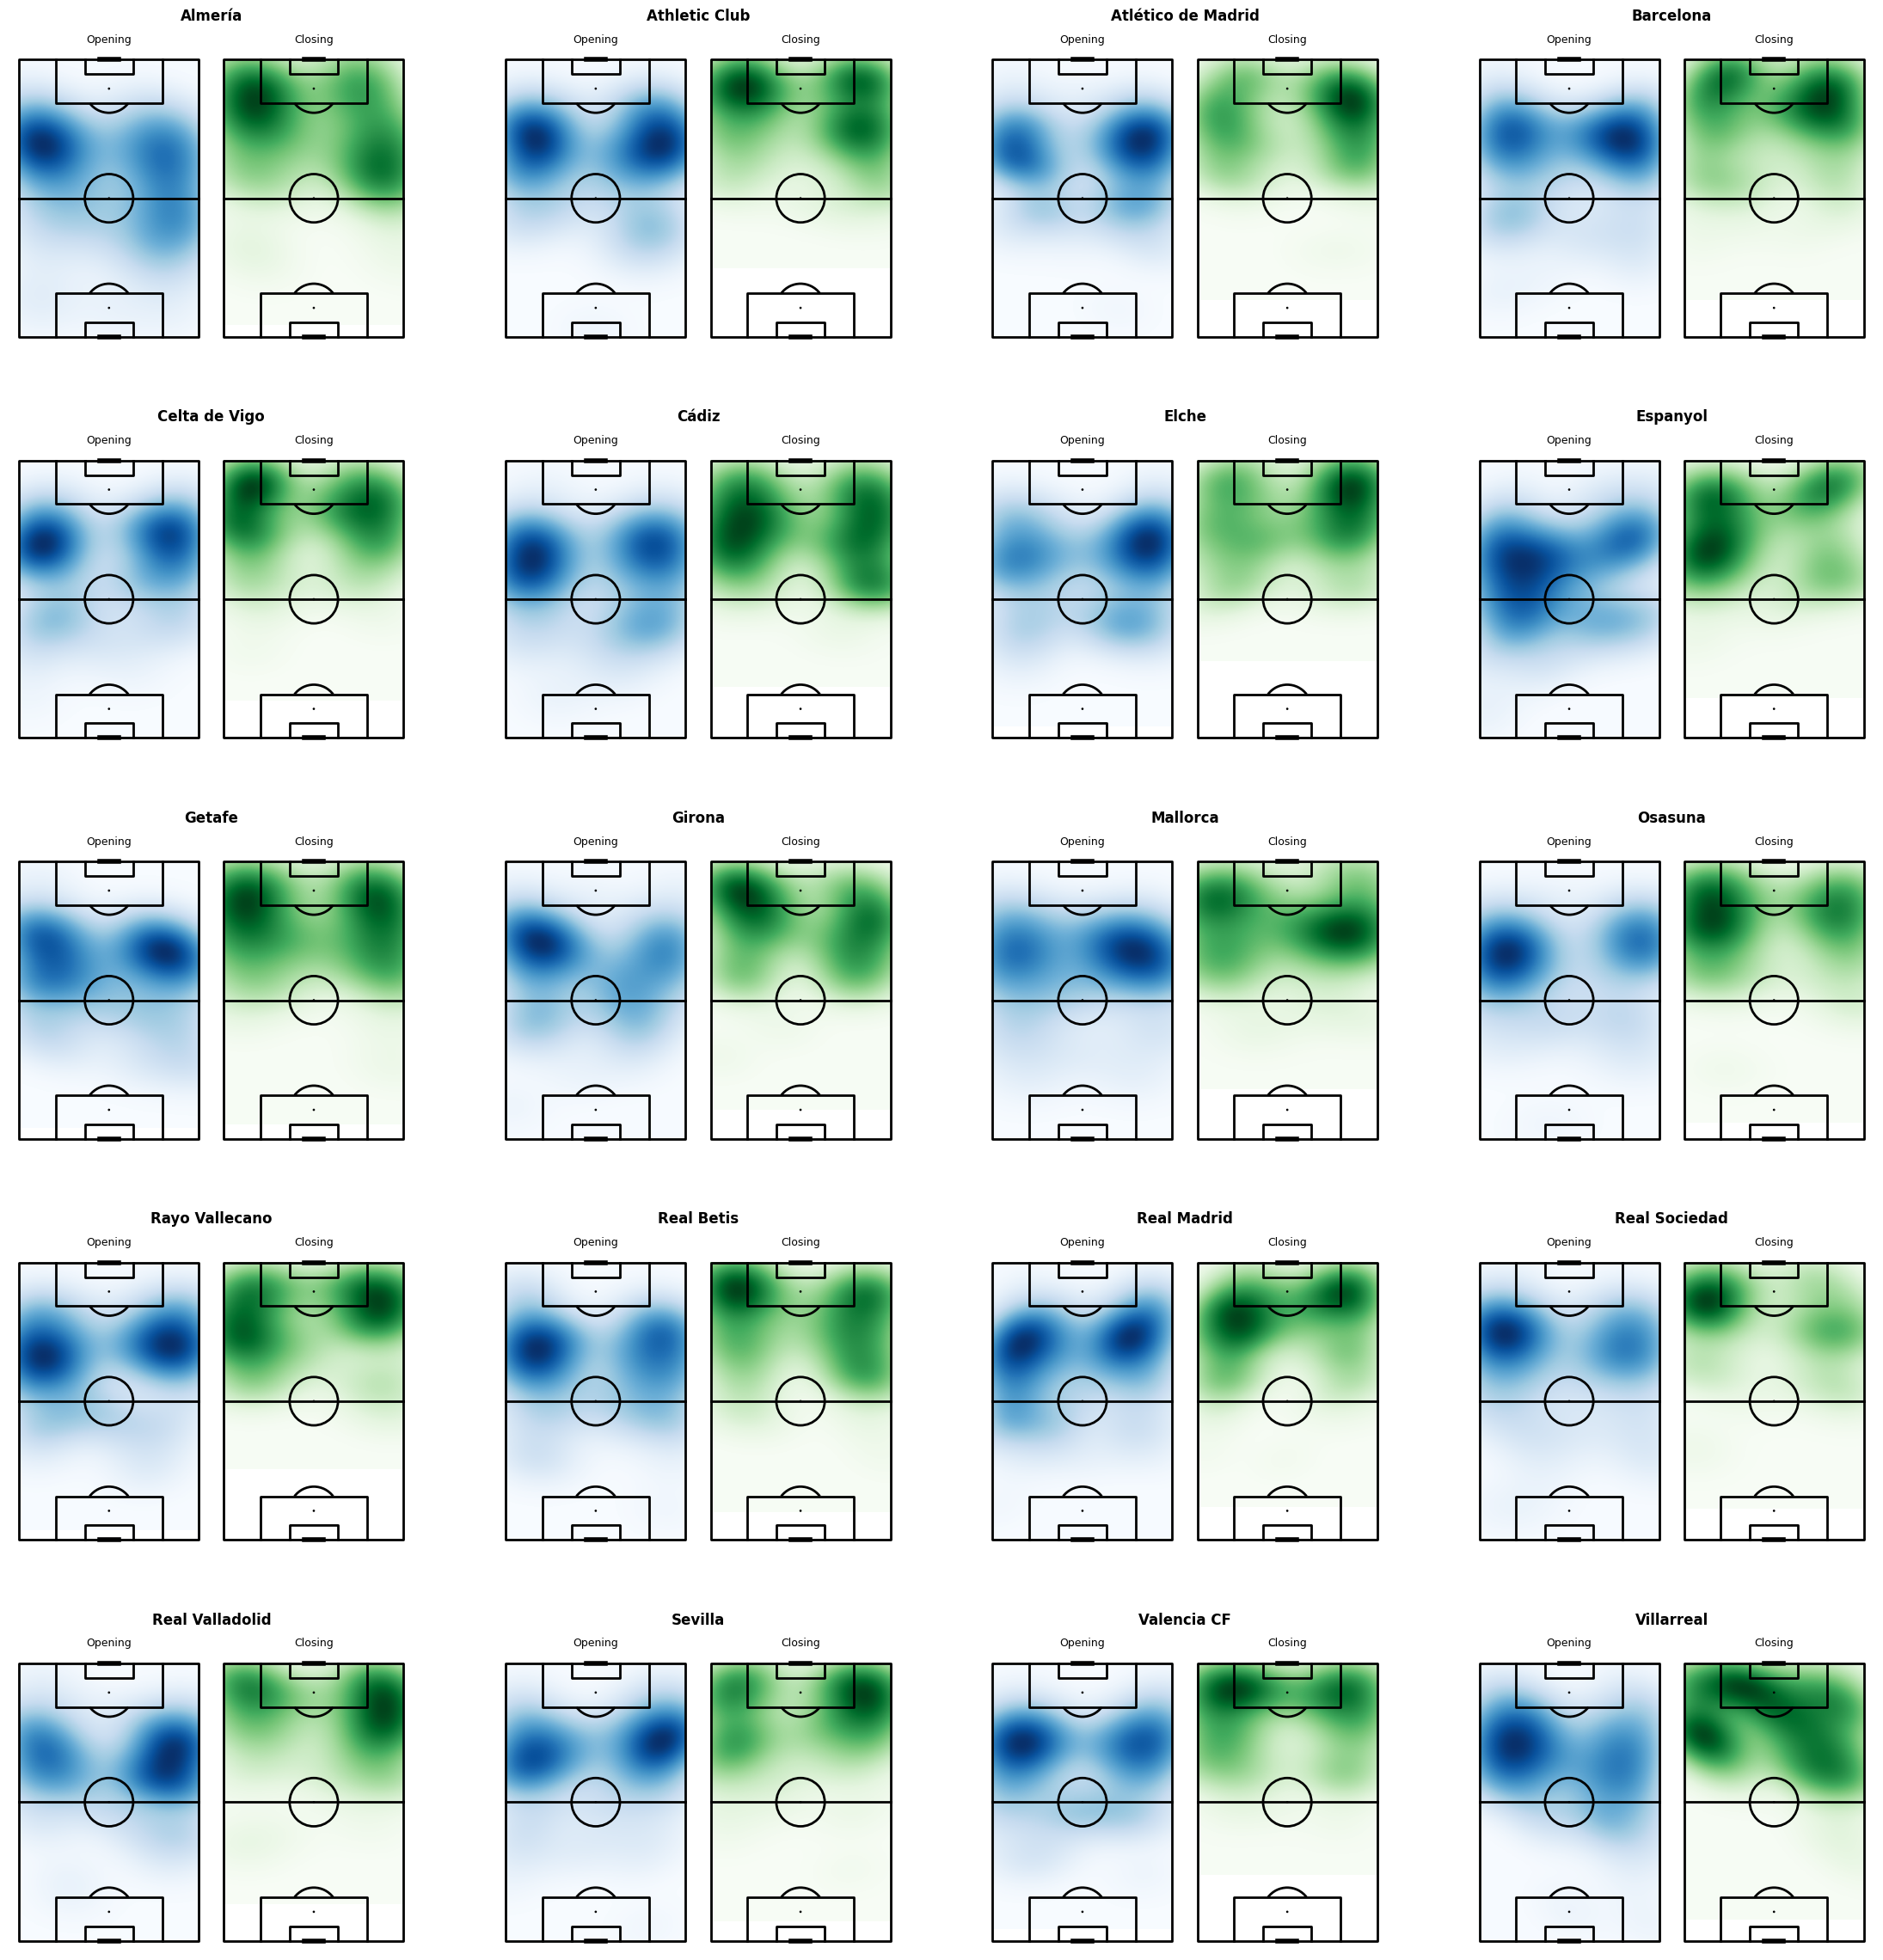

In [41]:
from typing import List

import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


def _truncate_cmap(cmap, minval=0.0, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})", new_colors
    )


def plot_one_twos_heatmap(
    df: pd.DataFrame,
    teams_per_row: int = 4,
    team_order: Optional[List[str]] = None,
    only_specified: bool = False,
) -> None:
    """
    Plot per-team heatmaps (Opening | Closing) for progressive one–twos.

      - Opening  : density of initiating pass start (x_A, y_A)
      - Closing  : density of return pass end (pass_end_x_B, pass_end_y_B)

    Parameters
    ----------
    df : DataFrame with columns [F.TEAM_NAME, f"{F.X}_A", f"{F.Y}_A",
                                 f"pass_end_{F.X}_B", f"pass_end_{F.Y}_B"]
    teams_per_row : number of teams per grid row
    team_order : list of team names specifying the desired plotting order
    only_specified : if True, plot only teams in `team_order`
    """
    # Unique teams present in data
    teams_in_data = df[F.TEAM_NAME].dropna().unique().tolist()

    if team_order is not None:
        # Keep order as provided, but only include teams that exist in the data
        wanted = [t for t in team_order if t in teams_in_data]
        if only_specified:
            teams = wanted
        else:
            remaining = [t for t in teams_in_data if t not in set(wanted)]
            teams = wanted + remaining
    else:
        teams = teams_in_data

    n_teams = len(teams)
    n_rows = int(np.ceil(n_teams / teams_per_row))

    fig = plt.figure(figsize=(3.5 * teams_per_row * 2, 6 * n_rows))
    outer = fig.add_gridspec(n_rows, teams_per_row, wspace=0.2, hspace=0.05)

    pitch = VerticalPitch(
        pitch_type="custom",
        pitch_width=68,
        pitch_length=105,
        pitch_color="white",
        line_color="black",
        line_zorder=3,
        shade_middle=True,
        shade_alpha=0.1,  # type: ignore
    )

    for idx, team in enumerate(teams):
        row = idx // teams_per_row
        col = idx % teams_per_row
        inner = outer[row, col].subgridspec(1, 2, wspace=0.02, width_ratios=[1, 1])

        team_df = df[df[F.TEAM_NAME] == team].copy()
        for c in [f"{F.X}_A", f"{F.Y}_A", f"pass_end_{F.X}_B", f"pass_end_{F.Y}_B"]:
            team_df[c] = pd.to_numeric(team_df[c], errors="coerce")

        # Opening
        ax_start = fig.add_subplot(inner[0, 0])
        pitch.draw(ax=ax_start)
        open_ok = team_df.dropna(subset=[f"{F.X}_A", f"{F.Y}_A"])
        if not open_ok.empty:
            pitch.kdeplot(
                x=open_ok[f"{F.X}_A"],
                y=open_ok[f"{F.Y}_A"],
                ax=ax_start,
                cmap="Blues",
                fill=True,
                thresh=0,
                levels=1000,
                zorder=1,
            )
        ax_start.set_title("Opening", fontsize=9)

        # Closing
        ax_end = fig.add_subplot(inner[0, 1])
        pitch.draw(ax=ax_end)
        close_ok = team_df.dropna(subset=[f"pass_end_{F.X}_B", f"pass_end_{F.Y}_B"])
        if not close_ok.empty:
            pitch.kdeplot(
                x=close_ok[f"pass_end_{F.X}_B"],
                y=close_ok[f"pass_end_{F.Y}_B"],
                ax=ax_end,
                cmap="Greens",
                fill=True,
                thresh=0,
                levels=1000,
                zorder=1,
            )
        ax_end.set_title("Closing", fontsize=9)

        # Team name centered above the duo
        left = ax_start.get_position().x0
        right = ax_end.get_position().x1
        top = ax_start.get_position().y1
        fig.text(
            (left + right) / 2,
            top + 0.01,
            str(team),
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()


# Example:
order = one_twos_per_game_.team_name.sort_values().unique()
plot_one_twos_heatmap(
    progressive_one_twos_df_, teams_per_row=4, team_order=order, only_specified=False
)

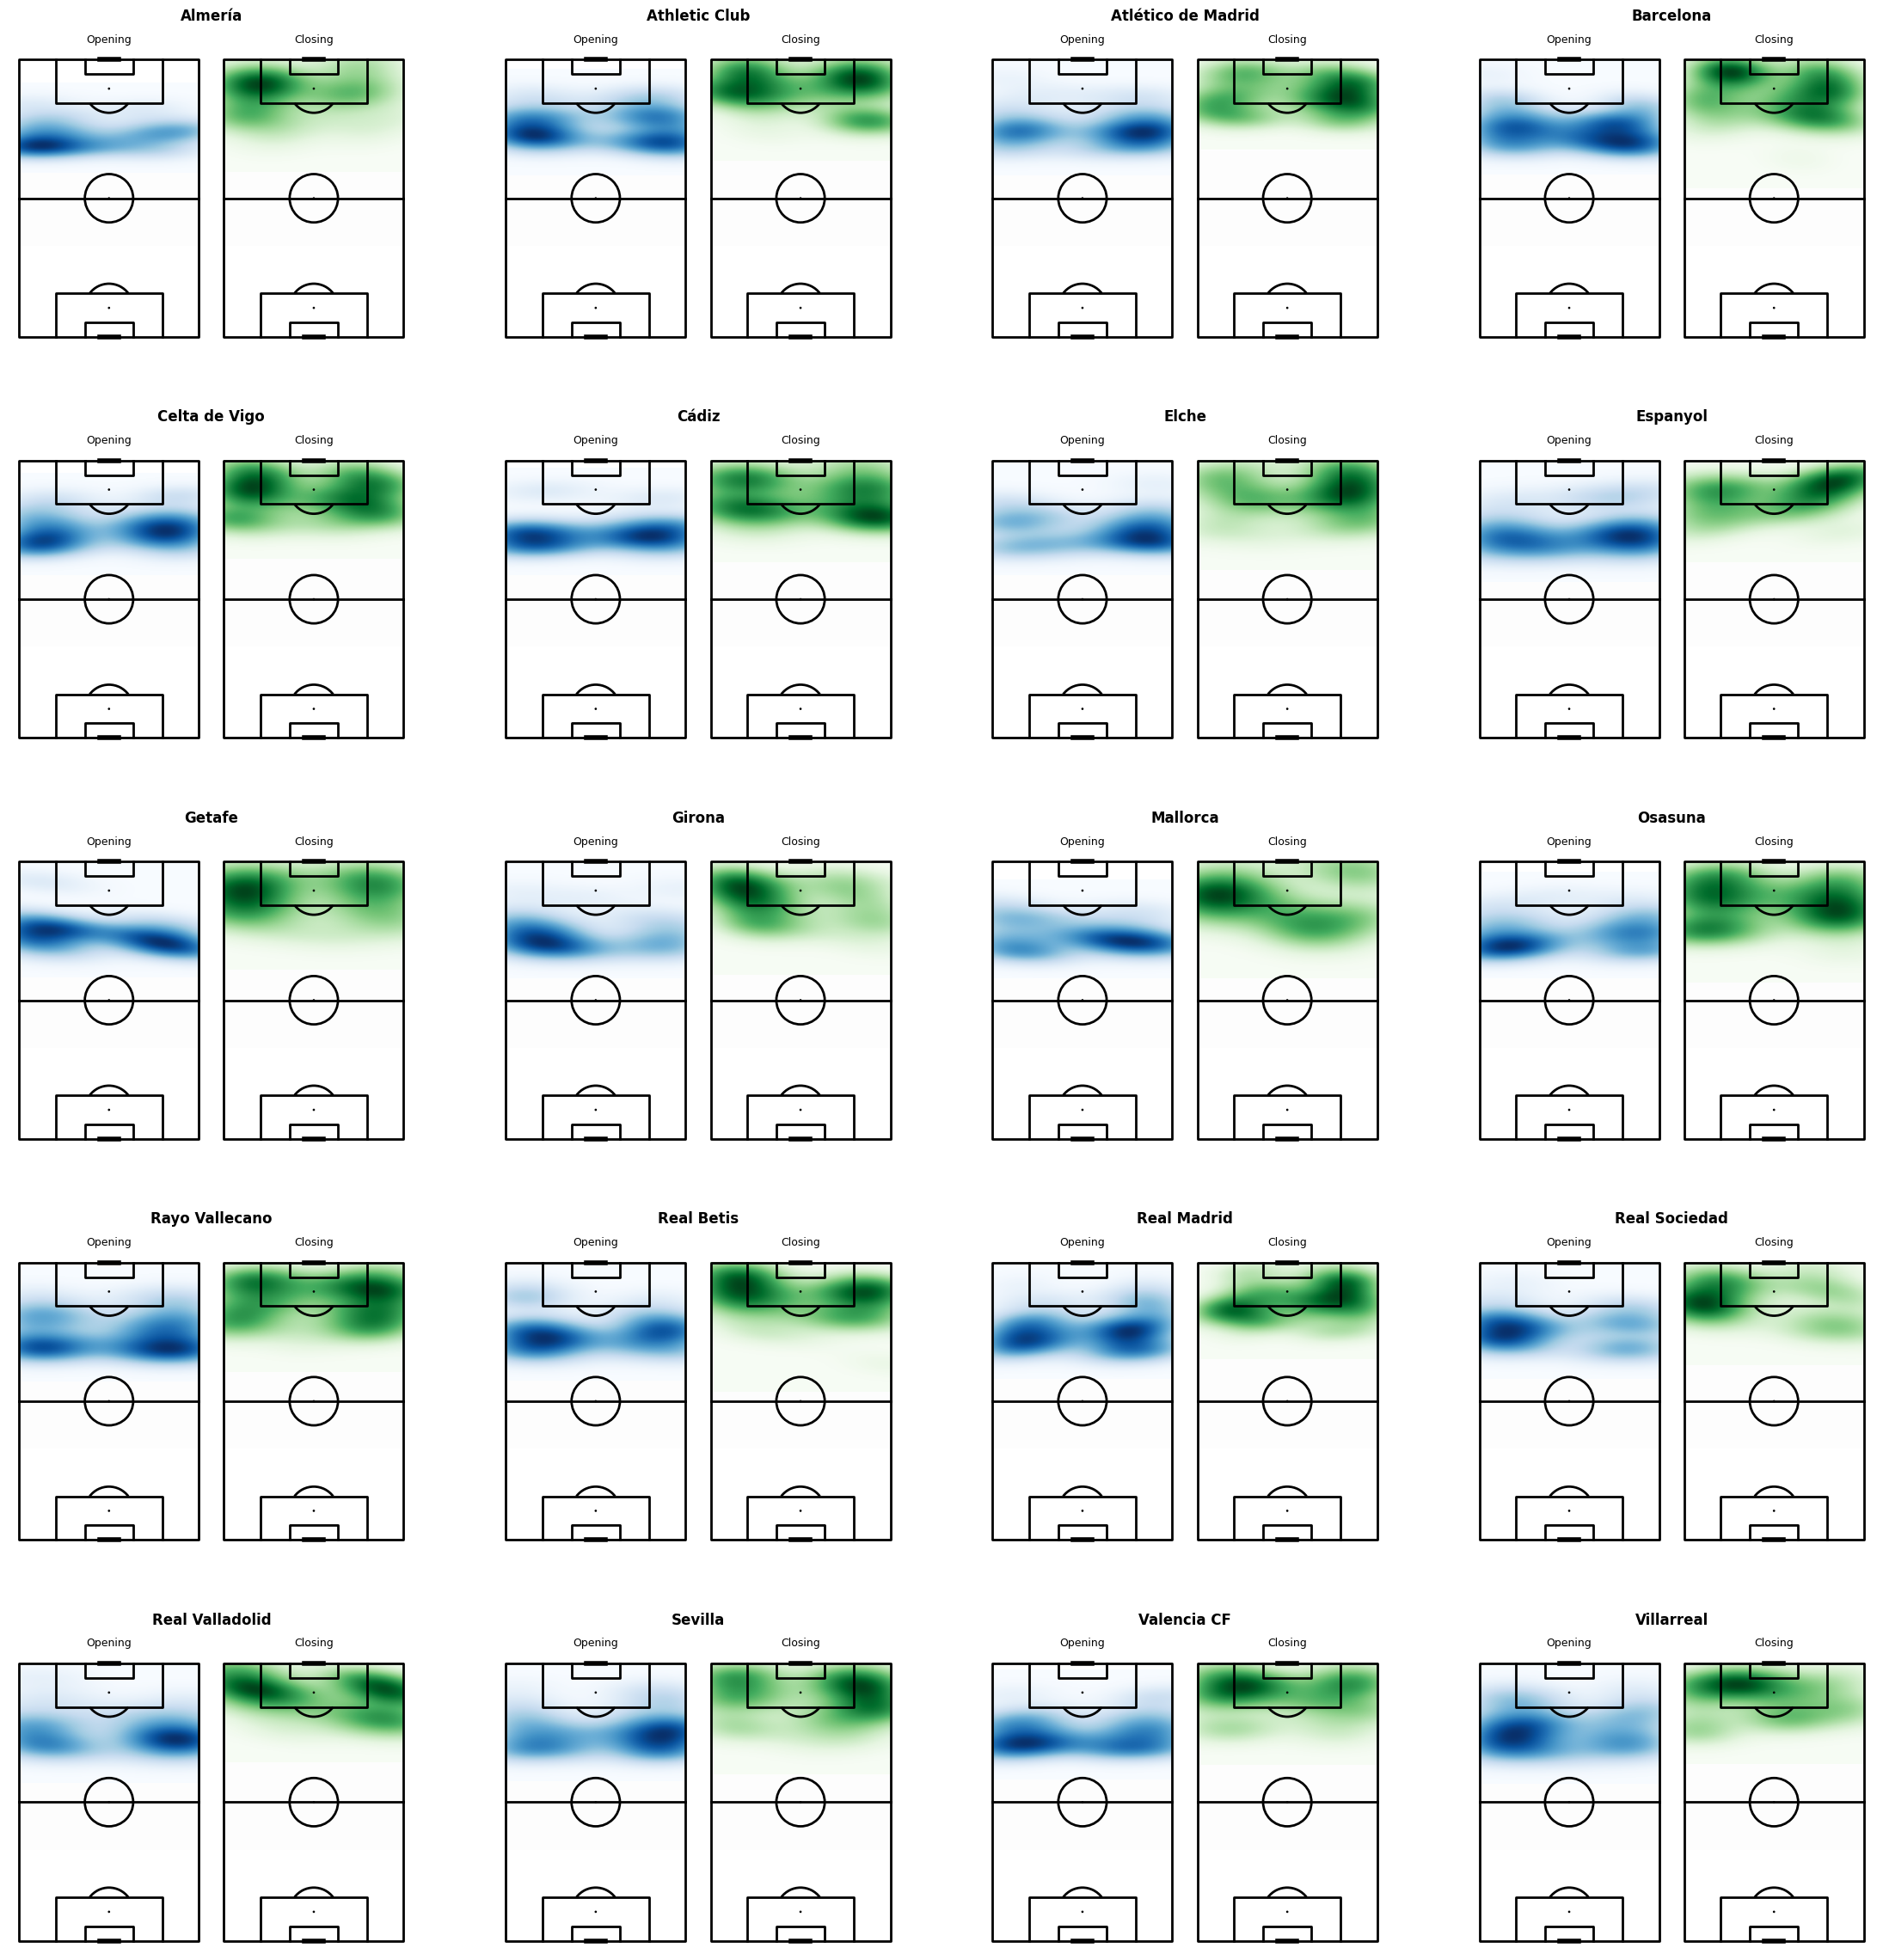

In [48]:
plot_one_twos_heatmap(
    progressive_one_twos_df_[progressive_one_twos_df_["x_A"] >= 70],
    teams_per_row=4,
    team_order=order,
    only_specified=False,
)

### Prog. One twos and chance creation (team - competition level)

- Most teams turn ~15–20% of their final-third progressive one-twos into chances.

- Villarreal, Real Madrid, and Celta Vigo stand out with a higher share of chances created directly off the one-two (larger dark bar).

- Celta are particularly efficient—about a quarter of their final-third one-twos become immediate chances. They also show plenty of chances one action later, consistent with flank-led combinations (e.g., overlapping/full-back involvement).

- Sevilla lag on conversion to chances (direct or next action) despite a high volume of one-twos per 90, suggesting execution/end-point issues rather than lack of combination play.

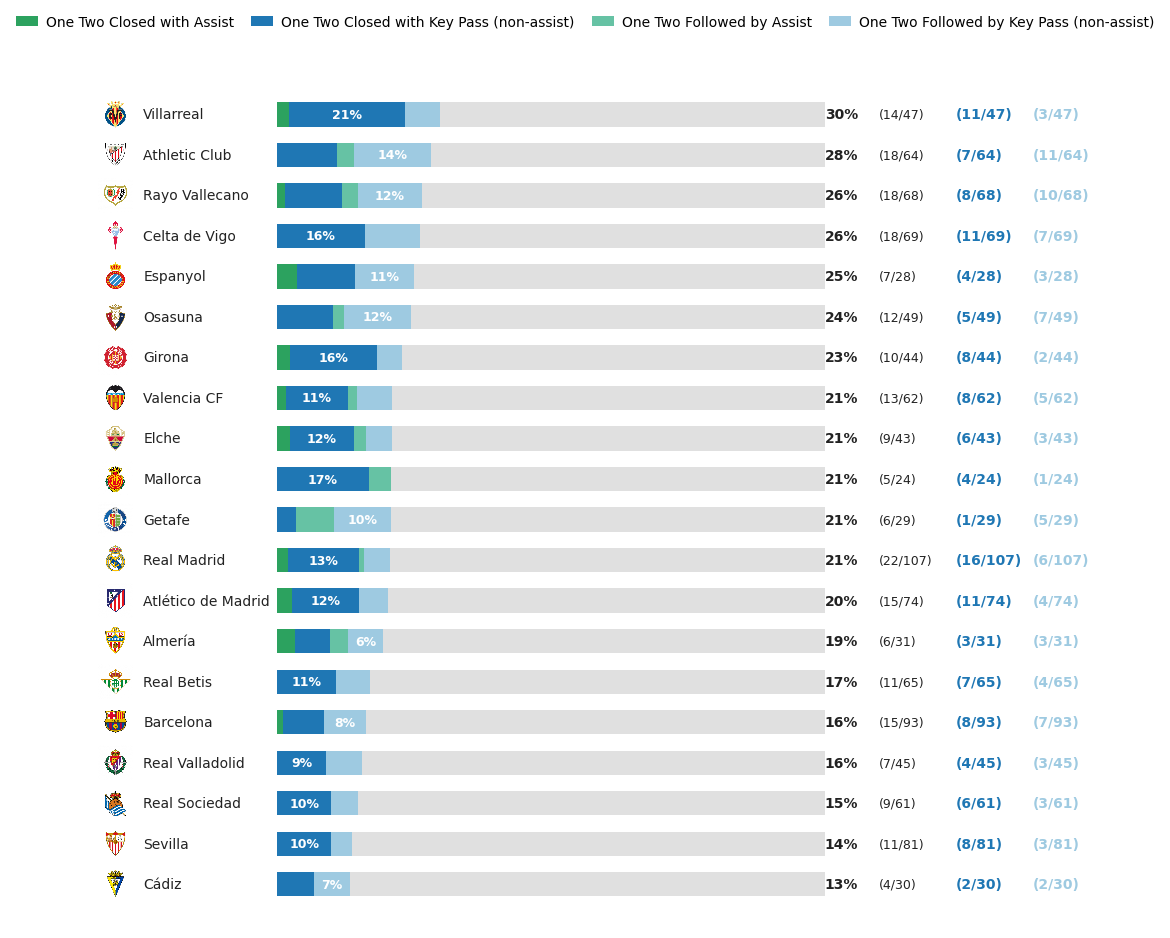

In [44]:
from typing import Optional

import pandas as pd


def plot_onetwos_chance_creation(
    df: pd.DataFrame,
    x_thresh: float = 70.0,
    logo_folder: Optional[str] = None,
    left_pad: float = 0.085,  # more gap between team name and bar (fixes long names)
) -> pd.DataFrame:
    """
    Final-third one–twos chance creation, stacked per team.

    Stacked (mutually exclusive):
      • Closed with ASSIST
      • Closed with Key Pass (non-assist)
      • Followed by ASSIST
      • Followed by Key Pass (non-assist)
      • Grey remainder to 100%

    Bars show *exclusive* KP portions (non-assist).
    Right-hand aligned columns (each team on one row):
      1) total % of FT one-twos leading to chance creation
      2) (events / FT)
      3) (closed / FT)    ← dark blue, bold
      4) (followed / FT)  ← light blue, bold
    """
    import os

    import matplotlib.pyplot as plt
    from matplotlib.offsetbox import AnnotationBbox, OffsetImage

    # ---- helpers ----
    def _pick(*cands):
        for c in cands:
            if c in df.columns:
                return c
        return None

    team_col = "team_name" if "team_name" in df.columns else "team_id"
    kp_b_col = _pick("keypass_B", "KEY_PASS_B")
    kp_n_col = _pick("keypass_next_B", "KEY_PASS_next_B")
    ast_b_col = _pick("assist_B", "ASSIST_B")
    ast_n_col = _pick("assist_next_B", "ASSIST_next_B")

    def _as_bool(series: Optional[pd.Series], index) -> pd.Series:
        if series is None:
            return pd.Series(False, index=index)
        return (
            series.fillna(0)
            .astype(str)
            .str.strip()
            .str.lower()
            .isin({"1", "true", "yes"})
        )

    # ---- filter to final third & build flags ----
    ft = df.loc[df["x_A"] >= x_thresh].copy()
    ft["kpB"] = _as_bool(ft.get(kp_b_col), ft.index)
    ft["kpN"] = _as_bool(ft.get(kp_n_col), ft.index)
    ft["astB"] = _as_bool(ft.get(ast_b_col), ft.index)
    ft["astN"] = _as_bool(ft.get(ast_n_col), ft.index)

    # exclusive KP-only (avoid double counting with assists)
    ft["kpB_only"] = ft["kpB"] & ~ft["astB"]
    ft["kpN_only"] = ft["kpN"] & ~ft["astN"]

    # ---- per-team aggregates ----
    stats = (
        ft.groupby(team_col, as_index=False)
        .agg(
            n_ft=("x_A", "size"),
            n_kpB=("kpB", "sum"),  # inclusive (reference)
            n_kpN=("kpN", "sum"),  # inclusive (reference)
            n_astB=("astB", "sum"),
            n_astN=("astN", "sum"),
            n_kpB_only=("kpB_only", "sum"),  # plotted
            n_kpN_only=("kpN_only", "sum"),  # plotted
        )
        .reset_index(drop=True)
    )

    # rates
    n = stats["n_ft"].replace(0, np.nan)
    stats["pct_kpB"] = (stats["n_kpB"] / n).fillna(0.0)  # inclusive (ref)
    stats["pct_kpNext"] = (stats["n_kpN"] / n).fillna(0.0)  # inclusive (ref)
    stats["pct_astB"] = (stats["n_astB"] / n).fillna(0.0)
    stats["pct_astNext"] = (stats["n_astN"] / n).fillna(0.0)
    stats["pct_kpB_only"] = (stats["n_kpB_only"] / n).fillna(0.0)  # plotted
    stats["pct_kpN_only"] = (stats["n_kpN_only"] / n).fillna(0.0)  # plotted

    # totals used for ordering and the right-hand numbers (what’s plotted)
    stats["total_plotted"] = (
        stats["pct_astB"]
        + stats["pct_kpB_only"]
        + stats["pct_astNext"]
        + stats["pct_kpN_only"]
    )

    # counts for right-hand aligned columns
    stats["closed_cnt"] = (stats["n_astB"] + stats["n_kpB_only"]).astype(int)
    stats["followed_cnt"] = (stats["n_astN"] + stats["n_kpN_only"]).astype(int)
    stats["num_plotted"] = (stats["closed_cnt"] + stats["followed_cnt"]).astype(int)
    stats["den_ft"] = stats["n_ft"].astype(int)

    # ---- order by total percentage (DESC — highest first) ----
    stats = stats.sort_values("total_plotted", ascending=True).reset_index(drop=True)

    # ---- stacked widths ----
    w_b_ast = stats["pct_astB"].to_numpy(float)
    w_b_kpo = stats["pct_kpB_only"].to_numpy(float)
    w_n_ast = stats["pct_astNext"].to_numpy(float)
    w_n_kpo = stats["pct_kpN_only"].to_numpy(float)
    colored_sum = stats["total_plotted"].to_numpy(float)
    w_grey = np.clip(1.0 - colored_sum, 0.0, None)
    y = np.arange(len(stats))

    # ---- plot ----
    bar_height, label_decimals = 0.60, 0
    fig_h = max(4.5, 0.45 * len(stats) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_h))

    # right-side aligned columns x-positions (tighter spacing)
    col1_x = left_pad + 1.00  # percentage
    col2_x = col1_x + 0.10  # (events/FT)
    col3_x = col2_x + 0.14  # (closed/FT)   dark blue, bold
    col4_x = col3_x + 0.14  # (followed/FT) light blue, bold

    # limits: include the far-right labels
    ax.set_xlim(-0.22, col4_x + 0.05)
    margin = bar_height * 1.8
    ax.set_ylim(-margin, len(stats) - 1 + margin)
    ax.set_yticks([])

    # colors
    col_astB, col_kpB = "#2ca25f", "#1f77b4"
    col_astN, col_kpN = "#66c2a4", "#9ecae1"
    col_g, col_text = "#e0e0e0", "#222"

    # draw bars with a fixed left gap
    left = np.full_like(w_b_ast, fill_value=left_pad, dtype=float)
    ax.barh(
        y,
        w_b_ast,
        left=left,
        height=bar_height,
        color=col_astB,
        edgecolor="none",
        label="One Two Closed with Assist",
    )
    left += w_b_ast
    ax.barh(
        y,
        w_b_kpo,
        left=left,
        height=bar_height,
        color=col_kpB,
        edgecolor="none",
        label="One Two Closed with Key Pass (non-assist)",
    )
    left += w_b_kpo
    ax.barh(
        y,
        w_n_ast,
        left=left,
        height=bar_height,
        color=col_astN,
        edgecolor="none",
        label="One Two Followed by Assist",
    )
    left += w_n_ast
    ax.barh(
        y,
        w_n_kpo,
        left=left,
        height=bar_height,
        color=col_kpN,
        edgecolor="none",
        label="One Two Followed by Key Pass (non-assist)",
    )
    left += w_n_kpo
    ax.barh(y, w_grey, left=left, height=bar_height, color=col_g, edgecolor="none")

    # clean axes
    ax.set_xticks([])
    ax.set_xlabel("")
    for s in ("left", "right", "top", "bottom"):
        ax.spines[s].set_visible(False)

    # team logos + names at left
    x_logo, x_text = -0.18, -0.16
    for i, name in enumerate(stats[team_col].astype(str)):
        if logo_folder:
            path = os.path.join(logo_folder, f"{name}.png")
            if os.path.exists(path):
                try:
                    img = Image.open(path)
                    ab = AnnotationBbox(
                        OffsetImage(img, zoom=0.08),
                        (x_logo, i),
                        frameon=False,
                        box_alignment=(1, 0.5),
                    )
                    ax.add_artist(ab)
                except Exception:
                    pass
        # name now has more room before the bar thanks to higher left_pad
        ax.text(x_text, i, name, va="center", ha="left", fontsize=10, color=col_text)

    # --- right-hand aligned columns ---
    for i, row in stats.iterrows():
        pct = row["total_plotted"] * 100.0

        # 1) percent column
        ax.text(
            col1_x,
            i,
            f"{pct:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            color=col_text,
            fontweight="bold",
        )

        # 2) (events/FT) column — neutral
        ax.text(
            col2_x,
            i,
            f"({row['num_plotted']}/{row['den_ft']})",
            va="center",
            ha="left",
            fontsize=9,
            color=col_text,
        )

        # 3) (closed/FT) — dark blue, bold
        ax.text(
            col3_x,
            i,
            f"({row['closed_cnt']}/{row['den_ft']})",
            va="center",
            ha="left",
            fontsize=10,
            color=col_kpB,
            fontweight="bold",
        )

        # 4) (followed/FT) — light blue, bold
        ax.text(
            col4_x,
            i,
            f"({row['followed_cnt']}/{row['den_ft']})",
            va="center",
            ha="left",
            fontsize=10,
            color=col_kpN,
            fontweight="bold",
        )

    # largest colored segment label (white, inside bars)
    segs = np.vstack([w_b_ast, w_b_kpo, w_n_ast, w_n_kpo]).T
    left_edges = np.vstack(
        [
            np.full_like(w_b_ast, left_pad),
            left_pad + w_b_ast,
            left_pad + w_b_ast + w_b_kpo,
            left_pad + w_b_ast + w_b_kpo + w_n_ast,
        ]
    ).T
    for i in range(len(stats)):
        widths = segs[i]
        if widths.max() <= 0:
            continue
        idxs = np.flatnonzero(widths == widths.max())
        centers = left_edges[i, idxs] + widths[idxs] / 2.0
        idx = int(idxs[np.argmax(centers)])
        width = float(widths[idx])
        cx = float(left_edges[i, idx] + width / 2.0)
        ax.text(
            cx,
            i,
            f"{width*100:.{label_decimals}f}%",
            va="center",
            ha="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=4,
        frameon=False,
        handlelength=1.6,
        columnspacing=1.2,
        handletextpad=0.6,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

    # return table aligned to what’s shown
    return stats[
        [
            team_col,
            "n_ft",
            "pct_astB",
            "pct_kpB_only",
            "pct_astNext",
            "pct_kpN_only",
            "pct_kpB",
            "pct_kpNext",  # inclusive KP (reference)
            "total_plotted",
            "num_plotted",
            "closed_cnt",
            "followed_cnt",
            "den_ft",
        ]
    ]


one_twos_chance_creation_stats = plot_onetwos_chance_creation(
    progressive_one_twos_df_, x_thresh=70, logo_folder=logos_folder_path
)

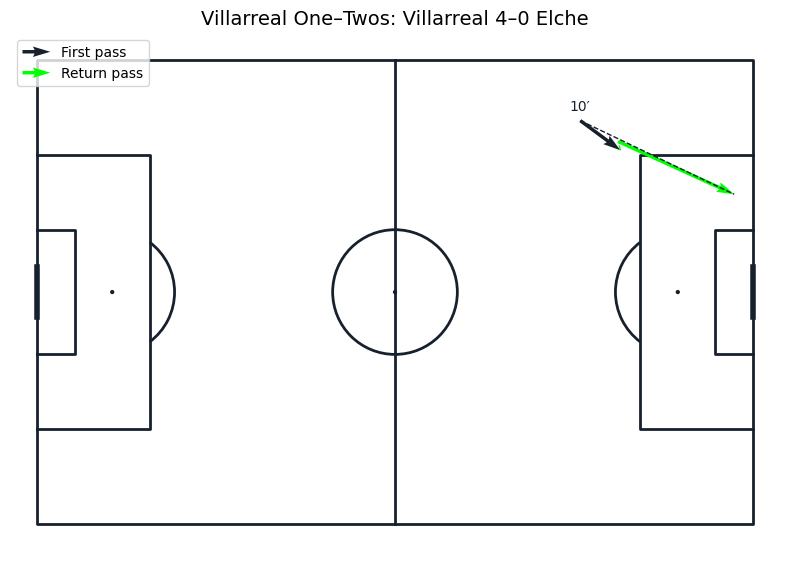

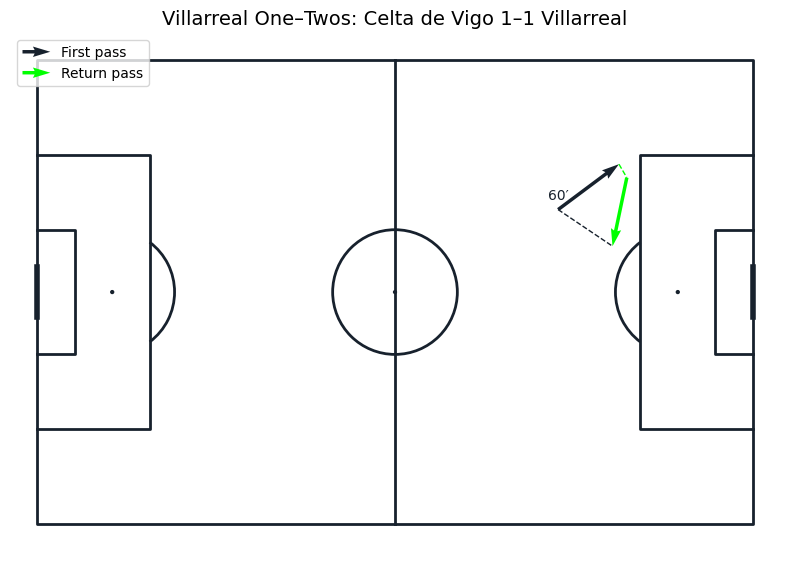

Skipping Villarreal-Rayo Vallecano: no Villarreal one–twos in current subset.
Skipping Elche-Villarreal: no Villarreal one–twos in current subset.
Skipping Villarreal-Barcelona: no Villarreal one–twos in current subset.


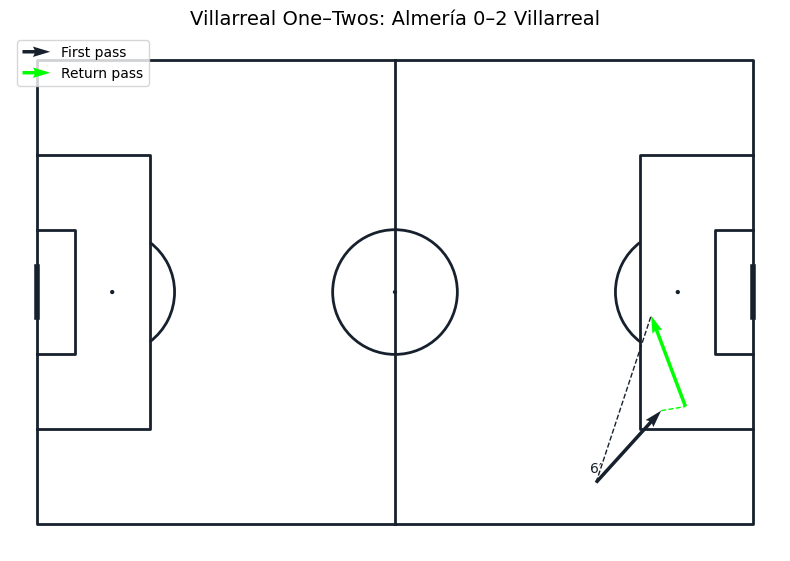

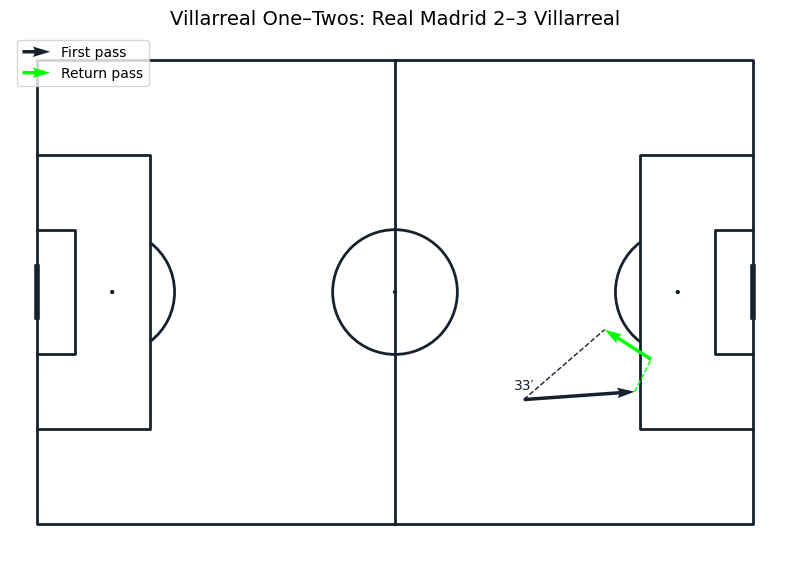

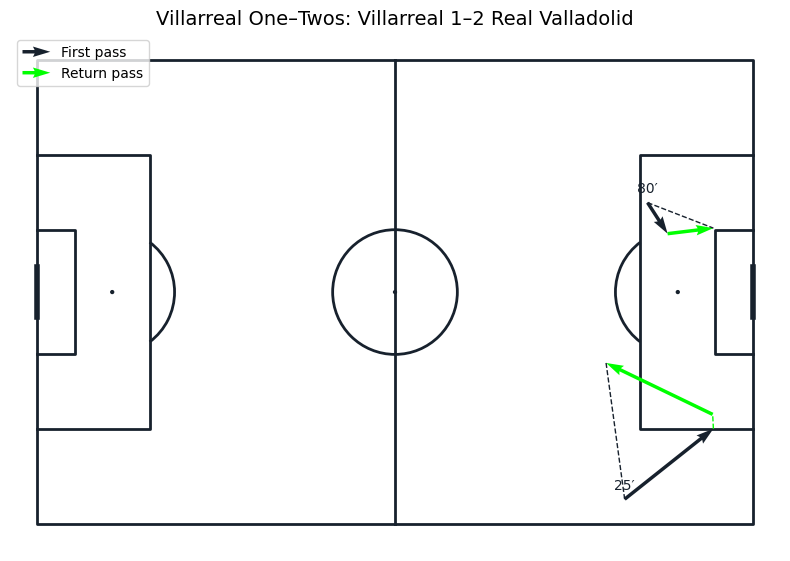

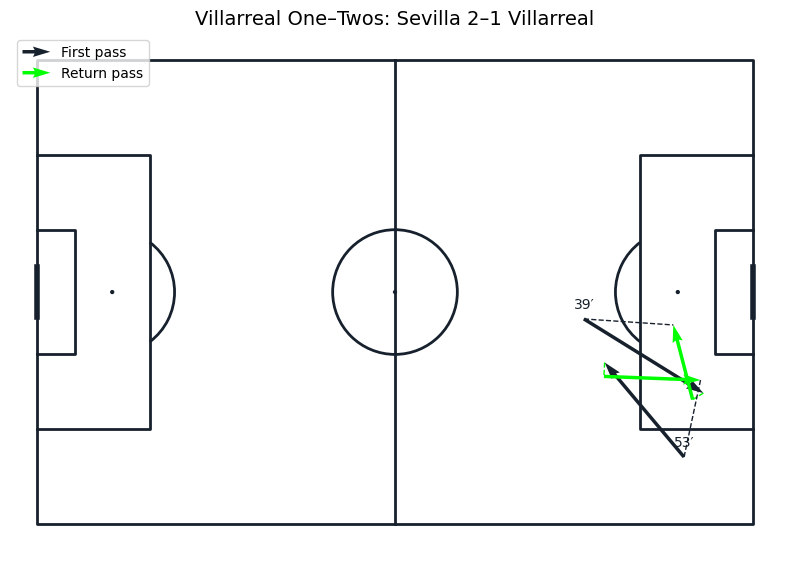

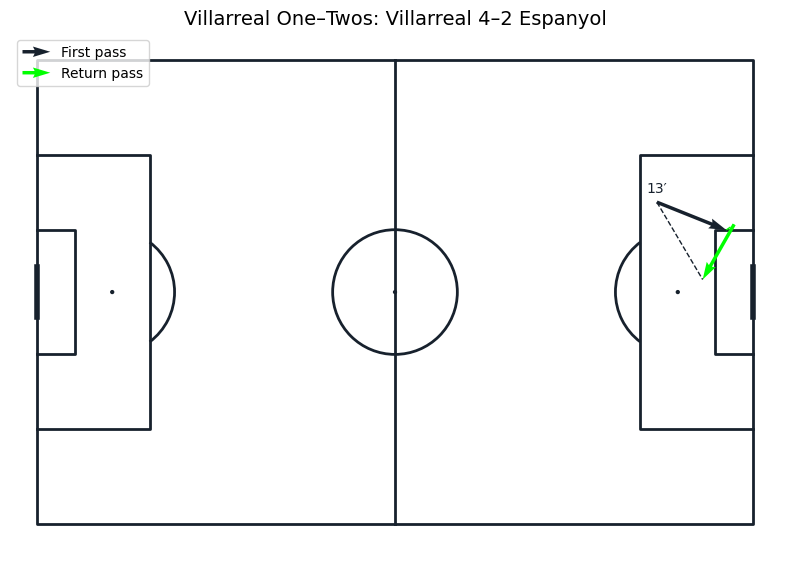

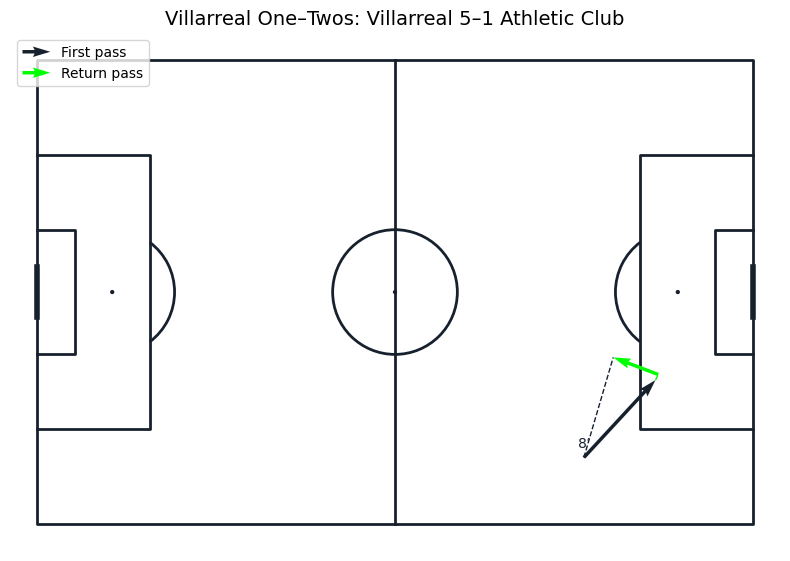

In [53]:
team_ = "Villarreal"
plot_team_one_twos(
    progressive_one_twos_df_[
        (progressive_one_twos_df_["keypass_B"] == "1")
        & (progressive_one_twos_df_["x_A"] >= 70)
    ],
    team_,
)

In [46]:
# EXPECTED THREATH GENERATION FROM PROGRESSIVE ONE TWOS
url_grid = "https://karun.in/blog/data/open_xt_12x8_v1.json"
xTModel = xthreat.load_model(url_grid)
progressive_one_twos_df_["xT_value"] = xTModel.rate(progressive_one_twos_df_)

/Users/benallalyoussef/miniconda3/envs/socceraction_/lib/python3.9/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'karun.in'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


In [56]:
# xT per 100 one–twos (efficiency metric)
res = (
    progressive_one_twos_df_[progressive_one_twos_df_["x_A"] >= 70]
    .dropna(subset=["team_name", "xT_value"])
    .groupby("team_name", as_index=False)
    .agg(one_twos=("xT_value", "size"), xT_sum=("xT_value", "sum"))
)

res["xT_per_100_one_twos"] = 100 * res["xT_sum"] / res["one_twos"]
res = res.sort_values("xT_per_100_one_twos", ascending=False)
res["xT_per_100_one_twos"] = res["xT_per_100_one_twos"].round(3)

res

,team_name,one_twos,xT_sum,xT_per_100_one_twos
19,Villarreal,47,1.294778,2.755
18,Valencia CF,62,1.534758,2.475
14,Real Madrid,107,2.631082,2.459
3,Barcelona,93,2.103416,2.262
0,Almería,31,0.604439,1.950
1,Athletic Club,64,1.171470,1.830
2,Atlético de Madrid,74,1.342157,1.814
4,Celta de Vigo,69,1.216438,1.763
9,Girona,44,0.742192,1.687
12,Rayo Vallecano,68,1.097479,1.614


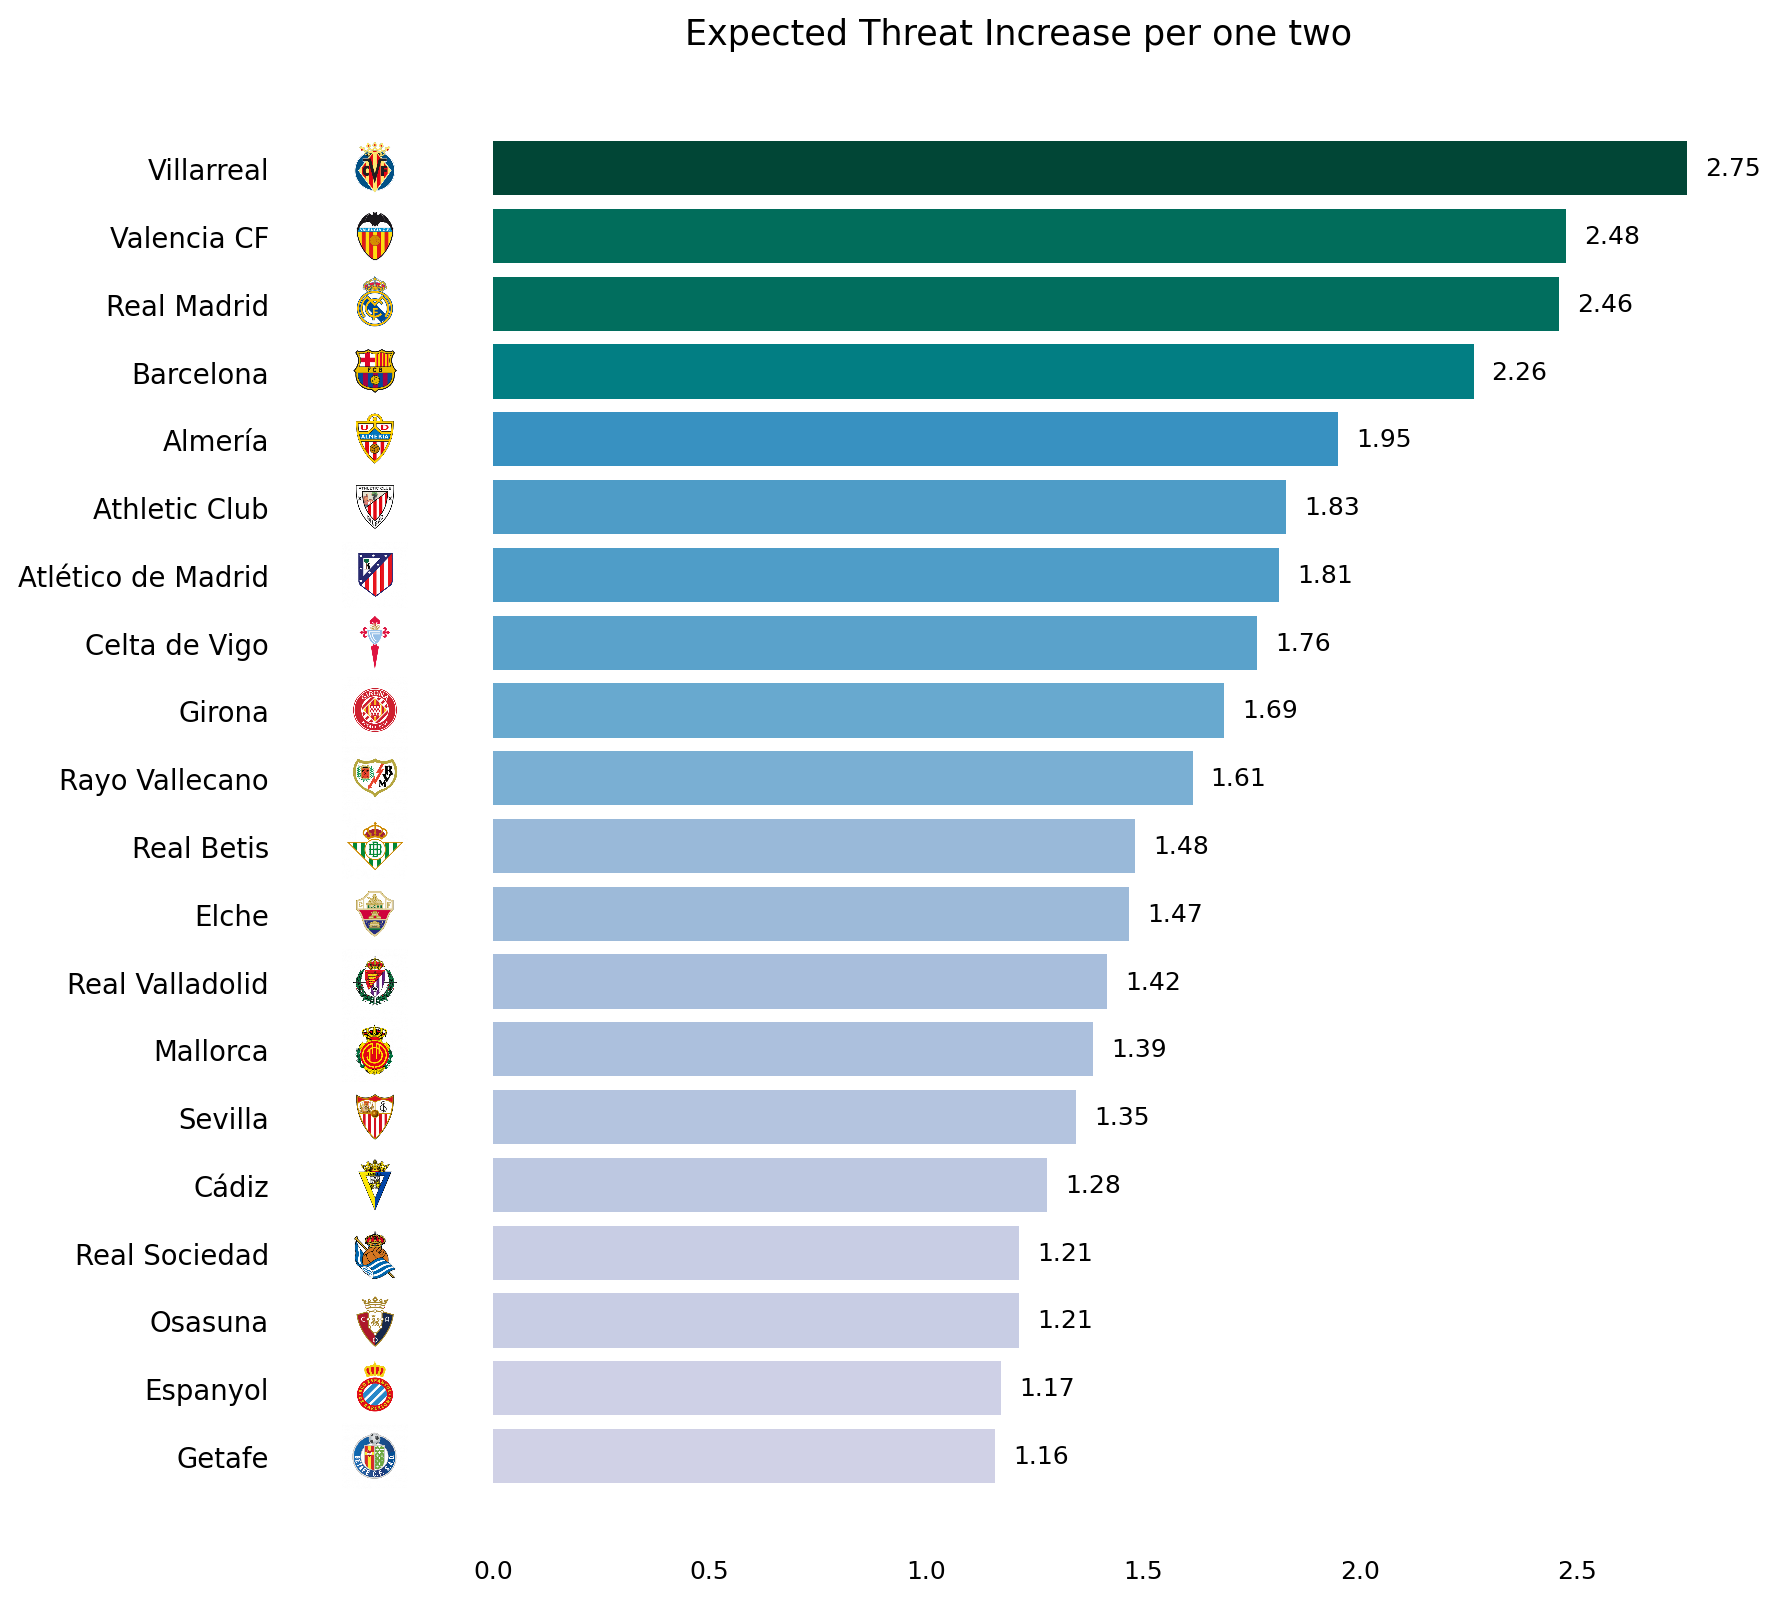

In [57]:
plot_one_twos_bar(
    res,
    logo_dir=logos_folder_path,
    team_col="team_name",
    kpi_col="xT_per_100_one_twos",
    title="Expected Threat Increase per one two",
)

### Prog. One twos involvement (player level)

* Scatter shows one-twos opened vs. closed per 90 mins for players with ≥1000 minutes (marker size ∝ minutes).
Most players tend to specialize: they either open the combo and carry/progress (right–below the diagonal) or close it by attacking the returned space (left–above the diagonal).

* Roles: With exceptions, fullbacks cluster below the y=x line (open more than they close → progressive overlaps), while wingers cluster above it (close more than they open → attracting defensive players and opens space).

* Two-way outliers: A few attacking players combine both volumes—e.g., Raphinha and Benzema sit high on closings while also opening near ~0.8 per 90; Aspas is similarly involved.

* Takeaway: The landscape is largely driven by the fullback–winger dynamic: fullbacks as initiators/runners, wingers as finishers of the wall-pass, with a handful of forwards contributing heavily to both buildup and chance creation.

In [95]:
scatter_tbl[scatter_tbl["player"].str.contains("Javi")]

,player_id,player,bucket,played_minutes,opened,closed,opened_p90,closed_p90
115,199259,Javi Sánchez,Other,2531.683333,4.0,0.0,0.142198,0.000000
143,219717,Javi Galán,Fullback,3347.133333,29.0,21.0,0.779772,0.564662
211,431434,Javi Puado,Winger,2432.683333,9.0,7.0,0.332966,0.258973
213,432838,Luis Javier Suárez,Forward,1611.900000,3.0,6.0,0.167504,0.335008
237,463163,Javi Hernández,Fullback,1201.366667,6.0,2.0,0.449488,0.149829


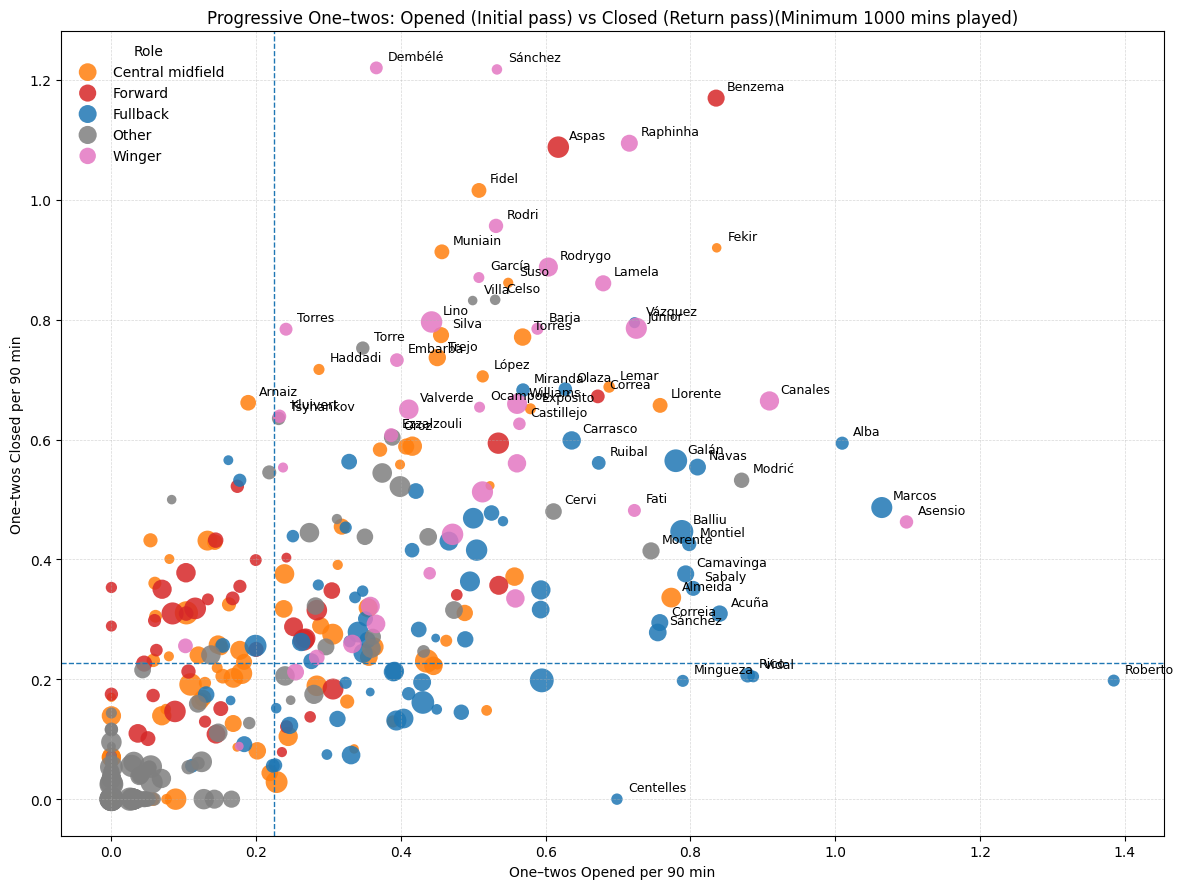

In [93]:
scatter_tbl = plot_onetwos_scatter_player(
    progressive_one_twos_df_, players_df, min_minutes=1000, label_thresh=0.6
)

### Prog. One twos duos (player level)

-- Note : Darker bar color means higher duo common minutes

- Quick takeaways (confirming the earlier scatter):

1. Dembélé–Sergi Roberto top the list for progressive one-twos per-90 (≈ 2 per game) across ~450 common minutes—and in this pair Roberto consistently initiates. A clear example is the combo leading to the goal vs Athletic Club that season.

2. Most leading pairs are same-flank partnerships (RB–RW or LB–LW), which fits the idea of short, progressive give-and-goes down the touchline.

3. Reliable duos showing up repeatedly and with consistence: Benzema–Rodrygo, Javi Galán–Luca de la Torre, Jesús Navas–Óliver Torres—each with ≥1200 common minutes and 10+ one-twos total, pointing to sustained, repeatable patterns.

4. Fekir and Canales are central operators who also combine frequently via one-twos, overperforming the average progressive one two involvement for their roles

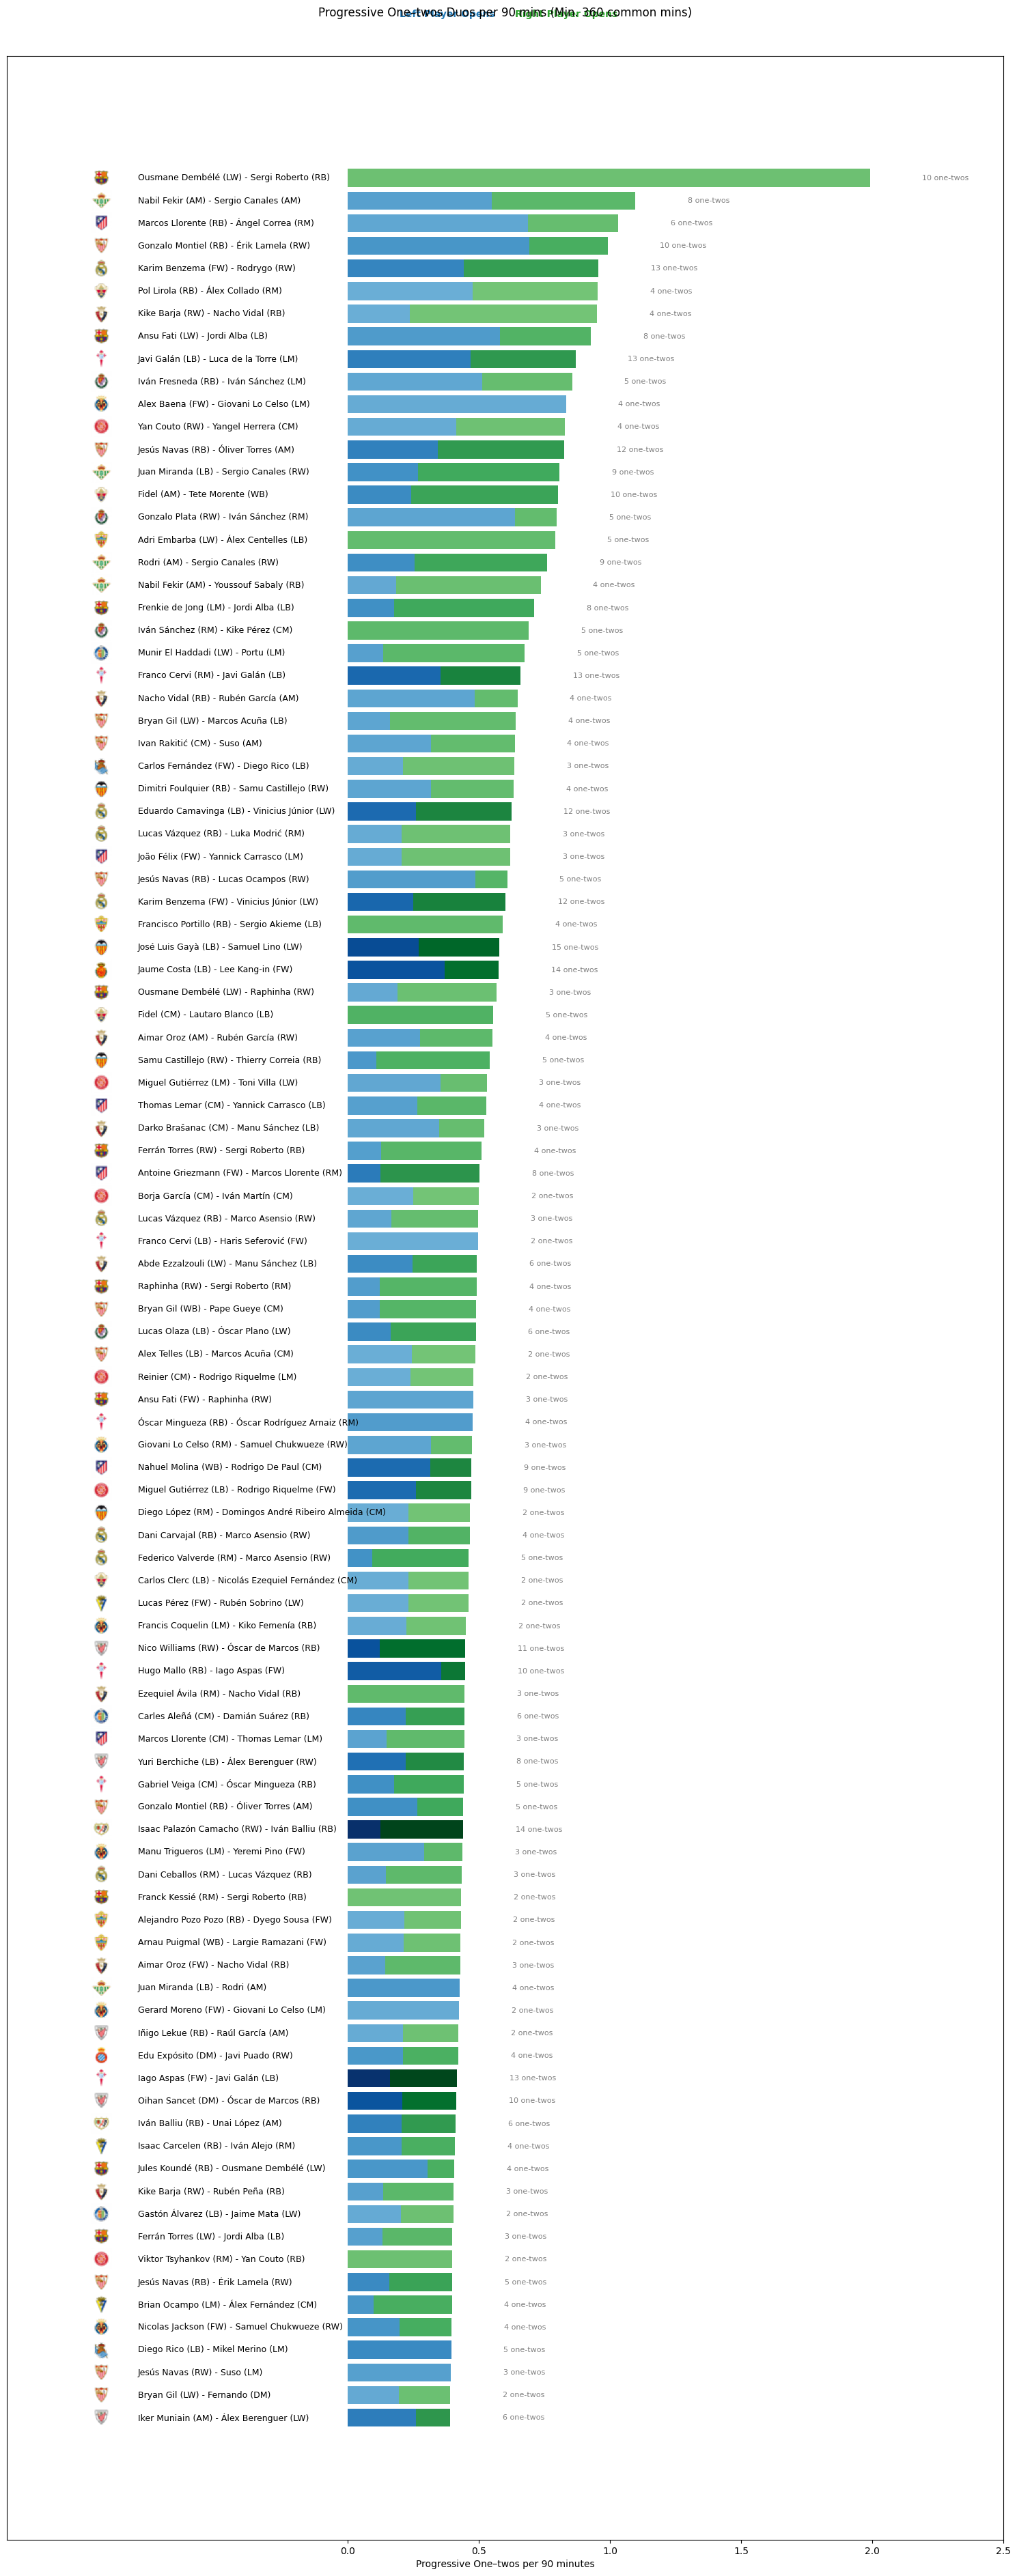

In [49]:
plot_one_twos_per_90(
    onetwos_pairs_df, progressive_one_twos_df_, 360, 100, logos_folder_path
)

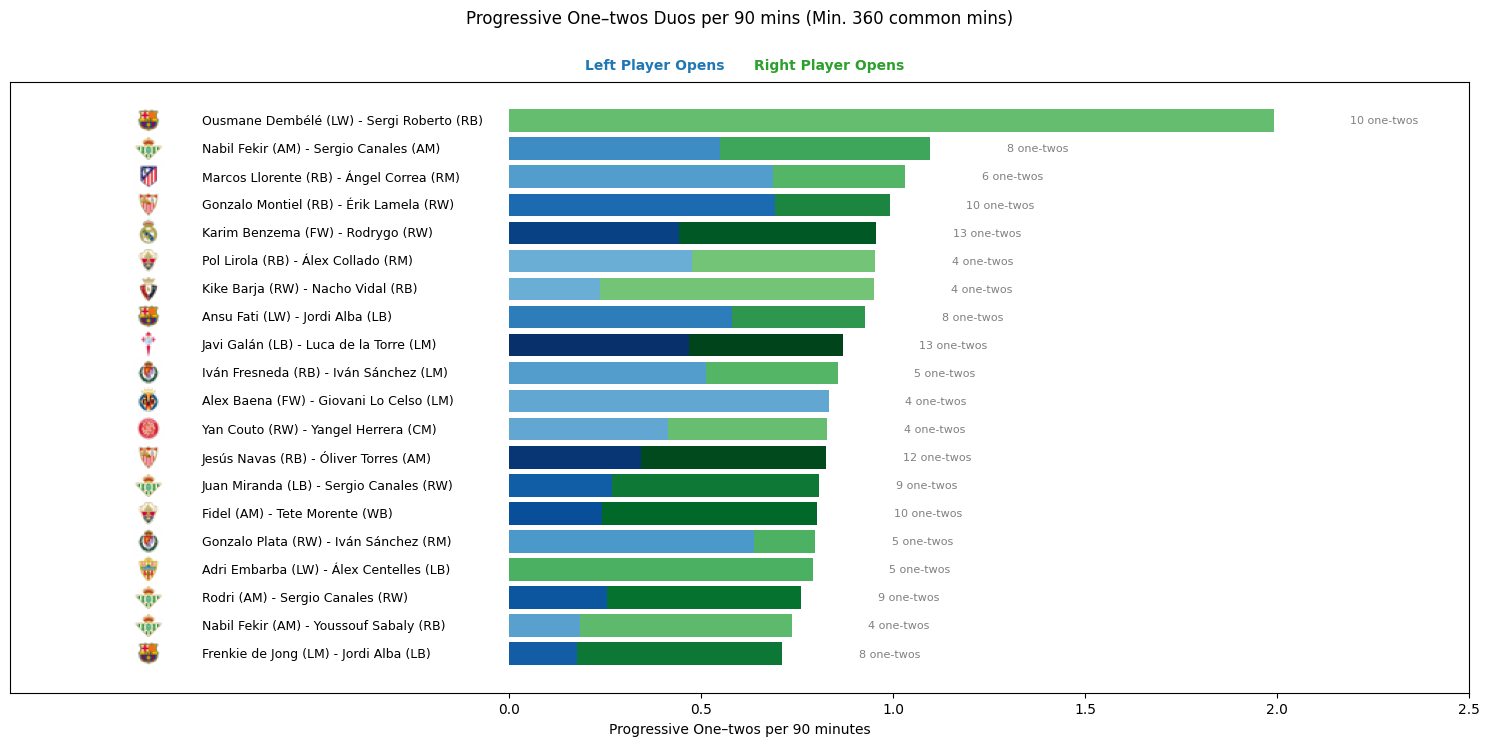

In [17]:
plot_one_twos_per_90(
    onetwos_pairs_df, progressive_one_twos_df_, 360, 20, logos_folder_path
)